# Test de différents modèles

## Modèle Explicatif (Taux vs Facteurs Environnementaux/Économiques)

### 🔄 Améliorations par rapport à NbCorrected.ipynb :

1. **Imputation sophistiquée** : Utilisation de `IterativeImputer` (via `data_preparation.py`) au lieu de la simple médiane
   - Forward/backward fill par pays pour les séries temporelles
   - IterativeImputer pour les valeurs manquantes restantes (méthode plus robuste)

2. **Encodage automatique** : Les pays (`Country Code`) sont automatiquement encodés en one-hot lors de l'imputation

3. **Pas de SMOTE** : Pour l'instant, nous n'utilisons pas SMOTE (commenté) pour évaluer les performances sans sur-échantillonnage

4. **Architecture simplifiée** : Pas de pipeline imbriqué - les données sont pré-traitées avant la modélisation


In [ ]:
# Définir le chemin de base
BASE_PATH = "/mnt/c/Users/ala78/OneDrive - HESSO/BA5/GML/data-gml-health/Refined"

# Définir le dossier
folder_name = "9019"

# Définir le nom du fichier
file_name = "COPD_prevalence_rate_s_2"

# Définir le format du fichier (csv, parquet, ...)
file_format = "csv"

# ============================================================================
# CONFIGURATION : Nombre de splits (répétitions) et seuil F1-score
# ============================================================================
N_SPLITS = 100  # Nombre de fois que l'on répète le split 80/20

# SEUIL F1-SCORE : Les modèles avec un F1-score inférieur à ce seuil
# ne contribueront PAS aux statistiques d'importance des features
F1_THRESHOLD = 0.7  # Seuil minimum de F1-score (0.0 à 1.0)

In [2]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import random

# Ajouter le dossier parent au path pour importer data_preparation
project_root = Path.cwd().parent    
sys.path.append(str(project_root.resolve()))

import COPD.data_preparation as data_preparation

# Chargement des données (adaptez le chemin selon votre fichier)
df = pd.read_csv(f"{BASE_PATH}/{folder_name}/{file_name}.{file_format}")

# Affichage des premières lignes pour vérifier les noms de colonnes
print("Aperçu des données :")
print(df.head())
print("\nNoms des colonnes :")
print(df.columns.tolist())
print("\nTypes de données :")
print(df.dtypes)


Aperçu des données :
      Measure Country Name                                Disease Metric  \
0  Prevalence    Indonesia  Chronic obstructive pulmonary disease   Rate   
1  Prevalence    Indonesia  Chronic obstructive pulmonary disease   Rate   
2  Prevalence    Indonesia  Chronic obstructive pulmonary disease   Rate   
3  Prevalence    Indonesia  Chronic obstructive pulmonary disease   Rate   
4  Prevalence    Indonesia  Chronic obstructive pulmonary disease   Rate   

   Year        Value Country Code  \
0  1990  1193.009546          IDN   
1  1991  1214.971198          IDN   
2  1992  1237.655515          IDN   
3  1993  1260.285392          IDN   
4  1994  1282.440639          IDN   

  Access to clean fuels and technologies for cooking (% of population)  \
0                                                 ..                     
1                                                 ..                     
2                                                 ..                     
3  

In [3]:
df.shape

(5212, 44)

### Étape 1 : Création de la variable cible (Y)

Au lieu de prédire le *changement* (Augmente/Diminue), nous allons prédire le *niveau* du taux lui-même.
Nous divisons le taux `Value` en 3 catégories (quantiles) pour équilibrer les classes :
- 0 : Faible
- 1 : Moyen
- 2 : Élevé

In [4]:
# Utilisation de qcut pour diviser les données en 3 quantiles (tertiles)
# Cela garantit une distribution à peu près égale des classes
try:
    df['Y_class'] = pd.qcut(df['Value'], q=3, labels=[0, 1, 2])
    df['Y_label'] = pd.qcut(df['Value'], q=3, labels=['Faible', 'Moyen', 'Élevé'])
except ValueError as e:
    print(f"Avertissement lors du qcut : {e}. Il peut y avoir des valeurs dupliquées.")
    # En cas d'échec (par exemple, trop de valeurs identiques), on force
    df['Y_class'] = pd.qcut(df['Value'], q=3, labels=[0, 1, 2], duplicates='drop')
    df['Y_label'] = pd.qcut(df['Value'], q=3, labels=['Faible', 'Moyen', 'Élevé'], duplicates='drop')

print("✓ Variable cible 'Y_class' (0=Faible, 1=Moyen, 2=Élevé) créée.")
print("\nDistribution de la nouvelle variable cible :")
print(df['Y_label'].value_counts())

print("\nExemple de données avec la nouvelle cible :")
print(df[['Country Name', 'Year', 'Value', 'Y_class', 'Y_label']].head())

✓ Variable cible 'Y_class' (0=Faible, 1=Moyen, 2=Élevé) créée.

Distribution de la nouvelle variable cible :
Y_label
Élevé     1738
Faible    1737
Moyen     1737
Name: count, dtype: int64

Exemple de données avec la nouvelle cible :
  Country Name  Year        Value Y_class Y_label
0    Indonesia  1990  1193.009546       1   Moyen
1    Indonesia  1991  1214.971198       1   Moyen
2    Indonesia  1992  1237.655515       1   Moyen
3    Indonesia  1993  1260.285392       1   Moyen
4    Indonesia  1994  1282.440639       1   Moyen


### Étape 1.5 : Préparation et Imputation des Données

Nous allons utiliser les fonctions de `data_preparation.py` pour :
1. Préprocesser les données (remplacer '..' et 'nan' par NaN)
2. Imputer les valeurs manquantes avec la méthode IterativeImputer (plus sophistiquée que la médiane simple)


In [5]:
# Sauvegarder Y_class et Y_label avant l'imputation
y_class_saved = df['Y_class'].copy()
y_label_saved = df['Y_label'].copy()

# Définir uniquement les colonnes à EXCLURE
# (Ce sont les métadonnées et les cibles)
cols_to_exclude = [
    'Measure', 
    'Country Name', 
    'Disease', 
    'Metric', 
    'Y_class', 
    'Y_label'
]

# Sélectionner les colonnes pour l'imputation
df_for_imputation = df.drop(columns=cols_to_exclude).copy()

print("\n⏳ Étape 1/2 : Preprocessing (remplacement de '..' et 'nan' par NaN)...")
df_prepared = data_preparation.preprocessing(df_for_imputation)

print(f"Nombre de NaN après preprocessing :")
print(df_prepared.isnull().sum().sum())

print("\n⏳ Étape 2/2 : Imputation des valeurs manquantes avec IterativeImputer...")
print("⚠️ Cette étape peut prendre quelques minutes...")
df_imputed = data_preparation.impute_nans(df_prepared)

print("\n✓ Imputation terminée !")
print(f"Nombre de NaN après imputation : {df_imputed.isnull().sum().sum()}")

# Récupérer les index originaux et ajouter Y_class et Y_label
df_imputed.index = df.index
df_imputed['Y_class'] = y_class_saved
df_imputed['Y_label'] = y_label_saved

print("\n✓ Données préparées et imputées avec succès !")
print(f"Forme finale : {df_imputed.shape}")

# Calcul de la vitesse du vent
df_imputed = data_preparation.process_wind_speed(df_imputed)



⏳ Étape 1/2 : Preprocessing (remplacement de '..' et 'nan' par NaN)...
Nombre de NaN après preprocessing :
44284

⏳ Étape 2/2 : Imputation des valeurs manquantes avec IterativeImputer...
⚠️ Cette étape peut prendre quelques minutes...
📊 Colonnes détectées pour l'imputation : 38 colonnes

🔄 Étape 1/3 : Interpolation temporelle linéaire...
📈 Interpolation temporelle : 23985 valeurs imputées sur 38 colonnes.
   NaN restants après interpolation : 20299

🔄 Étape 2/3 : Forward/Backward fill résiduel...

🔄 Étape 3/3 : Imputation MICE (IterativeImputer)...

✓ Imputation terminée !
Nombre de NaN après imputation : 0

✓ Données préparées et imputées avec succès !
Forme finale : (5212, 207)
✅ 'Wind_Speed' calculée. Colonnes 'u10' et 'v10' non supprimées.


In [6]:
df.shape

(5212, 46)

In [7]:
df

,Measure,Country Name,Disease,Metric,Year,Value,Country Code,Access to clean fuels and technologies for cooking (% of population),Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),...,skt,blh,PM2.5 pollution,Physicians per 1000,Population 60+ (%),Population 40-59 (%),Industry workers (%),Agriculture workers (%),Y_class,Y_label
0,Prevalence,Indonesia,Chronic obstructive pulmonary disease,Rate,1990,1193.009546,IDN,..,..,0.881619792814537,...,298.443682,416.995369,29.83680,0.144,6.53699,15.81951,NaN,NaN,1,Moyen
1,Prevalence,Indonesia,Chronic obstructive pulmonary disease,Rate,1991,1214.971198,IDN,..,48.9,0.935142133635504,...,298.402007,418.597569,29.53306,0.148,6.66254,15.81206,16.76361,46.82179,1,Moyen
2,Prevalence,Indonesia,Chronic obstructive pulmonary disease,Rate,1992,1237.655515,IDN,..,66.6965637207031,0.960601996980232,...,298.612211,442.807229,29.21366,NaN,6.79220,15.84033,17.09365,46.21633,1,Moyen
3,Prevalence,Indonesia,Chronic obstructive pulmonary disease,Rate,1993,1260.285392,IDN,..,55.43,1.03387458321859,...,298.473822,428.757010,28.88323,0.058,6.92725,15.90460,17.44782,45.51283,1,Moyen
4,Prevalence,Indonesia,Chronic obstructive pulmonary disease,Rate,1994,1282.440639,IDN,..,62.8,1.08216654865227,...,298.180950,402.532593,28.54637,NaN,7.06465,16.00095,17.91430,44.72863,1,Moyen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5207,Prevalence,Bahrain,Chronic obstructive pulmonary disease,Rate,2020,1567.048024,BHR,100,100,25.0267625954012,...,293.538177,818.405701,58.49506,NaN,5.91129,24.21196,34.99059,0.93477,1,Moyen
5208,Prevalence,Bahrain,Chronic obstructive pulmonary disease,Rate,2021,1622.777411,BHR,100,100,24.7782951610812,...,292.945099,794.708496,NaN,NaN,6.16968,23.58087,35.06124,0.91637,1,Moyen
5209,Prevalence,Sudan,Chronic obstructive pulmonary disease,Rate,2019,1514.562973,SDN,58.9,57.6,0.515394963684055,...,299.369651,819.350147,51.93562,NaN,4.86259,13.18383,13.72037,40.72942,1,Moyen
5210,Prevalence,Sudan,Chronic obstructive pulmonary disease,Rate,2020,1537.027363,SDN,61,59.7,0.456248148211711,...,298.836881,847.942231,45.83490,NaN,4.95129,13.21236,13.84309,40.79980,1,Moyen


### Étape 1.6 : Feature Engineering - Normalisation des Variables

Pour éviter les biais de corrélation avec la taille des pays, nous créons des features normalisées :
1. **Densité de population** : Remplace la surface (corrélée au pays) par une métrique démographique
2. **Suppression des colonnes totales redondantes** : Élimine les totaux quand une version per capita existe déjà (ex: garder "GDP per capita", supprimer "GDP total")
3. **Ratios per capita** : Transforme des valeurs absolues en valeurs normalisées par habitant
4. **Traitement des variables météo** : Supprime les températures redondantes (skt, d2m corrélées à t2m) et arrondit t2m et sst pour réduire le biais de précision

In [8]:
# FEATURE ENGINEERING : Création de ratios par rapport à la population

print("="*80)
print("LISTE DE TOUTES LES COLONNES DISPONIBLES POUR FEATURE ENGINEERING")
print("="*80)

# Exclure les colonnes de métadonnées et cibles
excluded_for_display = ['Value', 'Y_class', 'Y_label', 'Country Code', 'Year']
available_cols = [col for col in df_imputed.columns 
                  if col not in excluded_for_display and not col.startswith('Country Code_')]

# Afficher toutes les colonnes disponibles
for i, col in enumerate(available_cols, 1):
    print(f"{i:2d}. {col}")

print(f"\n{'='*80}")
print(f"Total : {len(available_cols)} colonnes disponibles")
print("="*80)

LISTE DE TOUTES LES COLONNES DISPONIBLES POUR FEATURE ENGINEERING
 1. Access to clean fuels and technologies for cooking (% of population)
 2. Access to electricity (% of population)
 3. Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
 4. Compulsory education, duration (years)
 5. GDP (current US$)
 6. GDP per capita (constant 2015 US$)
 7. Gini index
 8. Life expectancy at birth, total (years)
 9. Mortality rate, infant (per 1,000 live births)
10. People using at least basic sanitation services (% of population)
11. Population, total
12. Poverty headcount ratio at national poverty lines (% of population)
13. Renewable electricity output (% of total electricity output)
14. Surface area (sq. km)
15. Unemployment, total (% of total labor force) (national estimate)
16. CO2 emissions
17. Coal consumption
18. Energy use
19. Electricity use
20. Raw materials extracted
21. Oil consumption
22. Sulfur emission
23. Prevalence tobacco use
24. u10
25. v10
26. d2m
27. t2m

In [9]:
# CONFIGURATION : Définir manuellement les colonnes à normaliser par la population
# Ajoutez ou retirez des colonnes selon vos besoins

# Colonnes à transformer en ratio par habitant (per capita)
# Ces colonnes seront divisées par 'Population, total' et la colonne originale sera supprimée
cols_to_normalize_by_population = [
    'CO2 emissions',
    'Total sales of agricultural pesticides (tonnes)',
    'Coal consumption',
    'Energy use',
    'Electricity use',
    'Raw materials extracted',
    'Oil consumption',
    'Sulfur emission',
    'PM2.5 pollution',
    # Ajoutez d'autres colonnes ici selon vos besoins
]

# Colonnes TOTALES à supprimer car elles ont déjà une version per capita
# (ex: 'GDP per capita' existe déjà, donc on supprime 'GDP (current US$)' qui est redondant)
cols_to_drop_total_have_per_capita = [
    'GDP (current US$)',
    'Surface area (sq. km)',
    'Population, total',  # Sera utilisée pour les calculs mais supprimée à la fin
    # Ajoutez d'autres colonnes TOTALES ici selon vos besoins
]

# Colonnes météo redondantes à supprimer (corrélation = 1 avec t2m)
cols_meteo_redundant = ['skt', 'd2m']

# Colonnes météo à arrondir (trop précises, causent du biais)
cols_meteo_to_round = ['t2m', 'sst']

print("📊 FEATURE ENGINEERING - NORMALISATION DES VARIABLES")
print("="*80)

# ========== ÉTAPE 1 : CALCUL DE LA DENSITÉ DE POPULATION ==========
print("\n[1/4] Calcul de la Densité de Population")
print("-" * 80)

if 'Population, total' in df_imputed.columns and 'Surface area (sq. km)' in df_imputed.columns:
    # Calculer la densité (éviter division par zéro)
    df_imputed['Population Density (per sq. km)'] = (
        df_imputed['Population, total'] / df_imputed['Surface area (sq. km)'].replace(0, np.nan)
    )
    
    print(f"✓ Densité calculée : Population Density (per sq. km)")
    print(f"  Stats - Min: {df_imputed['Population Density (per sq. km)'].min():.2f} | "
          f"Max: {df_imputed['Population Density (per sq. km)'].max():.2f} | "
          f"Mean: {df_imputed['Population Density (per sq. km)'].mean():.2f} hab/km²")
else:
    print("⚠️  Colonnes manquantes - Densité non calculée")

# ========== ÉTAPE 2 : CRÉATION DE RATIOS PER CAPITA ==========
print(f"\n[2/4] Création de Ratios Per Capita")
print("-" * 80)
print(f"Colonnes à normaliser : {len(cols_to_normalize_by_population)}\n")

if 'Population, total' not in df_imputed.columns:
    print("❌ ERREUR : La colonne 'Population, total' n'existe pas !")
    print("   Impossible de calculer les ratios.")
else:
    # Créer les ratios
    created_features = []
    removed_features = []
    
    for col in cols_to_normalize_by_population:
        if col in df_imputed.columns:
            # Créer le nom de la nouvelle colonne
            new_col_name = f"{col} (per capita)"
            
            # Calculer le ratio (éviter division par zéro)
            df_imputed[new_col_name] = df_imputed[col] / df_imputed['Population, total'].replace(0, np.nan)
            
            # Supprimer l'ancienne colonne
            df_imputed = df_imputed.drop(columns=[col])
            
            created_features.append(new_col_name)
            removed_features.append(col)
            
            print(f"✓ {col}")
            print(f"  → Créé : {new_col_name}")
            print(f"  → Supprimé : {col}\n")
        else:
            print(f"⚠️  {col} - NON TROUVÉE (ignorée)\n")

# ========== ÉTAPE 3 : SUPPRESSION DES COLONNES TOTALES (ont déjà une version per capita) ==========
print(f"\n[3/4] Suppression des Colonnes Totales (ont déjà une version per capita)")
print("-" * 80)

dropped_totals = []
for col in cols_to_drop_total_have_per_capita:
    if col in df_imputed.columns:
        df_imputed = df_imputed.drop(columns=[col])
        dropped_totals.append(col)
        print(f"✓ Supprimé : {col}")
    else:
        print(f"⚠️  {col} - NON TROUVÉE (ignorée)")

if dropped_totals:
    print(f"\n  Total colonnes totales supprimées : {len(dropped_totals)}")
else:
    print("\n  Aucune colonne à supprimer")

# ========== ÉTAPE 4 : TRAITEMENT DES VARIABLES MÉTÉOROLOGIQUES ==========
print(f"\n[4/4] Traitement des Variables Météorologiques")
print("-" * 80)

# Suppression des températures redondantes (corrélation = 1 avec t2m)
dropped_meteo = []
for col in cols_meteo_redundant:
    if col in df_imputed.columns:
        df_imputed = df_imputed.drop(columns=[col])
        dropped_meteo.append(col)
        print(f"✓ Supprimé (redondant avec t2m) : {col}")
    else:
        print(f"⚠️  {col} - NON TROUVÉE (ignorée)")

# Arrondissement des températures trop précises
rounded_meteo = []
for col in cols_meteo_to_round:
    if col in df_imputed.columns:
        print(f"📊 {col} - Avant arrondissement:")
        print(f"  Exemples de valeurs: {df_imputed[col].head(10).tolist()}")
        print(f"  Nombre de valeurs uniques: {df_imputed[col].nunique()}")
        
        df_imputed[col] = df_imputed[col].round(2)
        rounded_meteo.append(col)
        
        print(f"✓ Arrondi à 1 décimale : {col}")
        print(f"  Exemples après arrondissement: {df_imputed[col].head(10).tolist()}")
        print(f"  Nombre de valeurs uniques après arrondissement: {df_imputed[col].nunique()}\n")
    else:
        print(f"⚠️  {col} - NON TROUVÉE (ignorée)")

if dropped_meteo or rounded_meteo:
    print(f"\n  Colonnes météo supprimées : {len(dropped_meteo)}")
    print(f"  Colonnes météo arrondies : {len(rounded_meteo)}")
else:
    print("\n  Aucune modification météo")

print("\n" + "="*80)
print("📈 RÉSUMÉ DES TRANSFORMATIONS")
print("="*80)
print(f"Features créées  : {len(created_features) + 1}")  # +1 pour la densité
print(f"Features supprimées : {len(removed_features) + len(dropped_totals) + len(dropped_meteo)}")
print(f"  - Colonnes normalisées (remplacées) : {len(removed_features)}")
print(f"  - Colonnes totales (ont déjà version per capita) : {len(dropped_totals)}")
print(f"  - Colonnes météo redondantes : {len(dropped_meteo)}")
print(f"Features arrondies : {len(rounded_meteo)} (températures)")
print(f"Forme du DataFrame : {df_imputed.shape}")
print("="*80)

📊 FEATURE ENGINEERING - NORMALISATION DES VARIABLES

[1/4] Calcul de la Densité de Population
--------------------------------------------------------------------------------
✓ Densité calculée : Population Density (per sq. km)
  Stats - Min: 1.34 | Max: 7856.16 | Mean: 157.90 hab/km²

[2/4] Création de Ratios Per Capita
--------------------------------------------------------------------------------
Colonnes à normaliser : 9

✓ CO2 emissions
  → Créé : CO2 emissions (per capita)
  → Supprimé : CO2 emissions

⚠️  Total sales of agricultural pesticides (tonnes) - NON TROUVÉE (ignorée)

✓ Coal consumption
  → Créé : Coal consumption (per capita)
  → Supprimé : Coal consumption

✓ Energy use
  → Créé : Energy use (per capita)
  → Supprimé : Energy use

✓ Electricity use
  → Créé : Electricity use (per capita)
  → Supprimé : Electricity use

✓ Raw materials extracted
  → Créé : Raw materials extracted (per capita)
  → Supprimé : Raw materials extracted

✓ Oil consumption
  → Créé : Oil con

### Étape 2 : Définition des Features (X)

Nous utilisons toutes les colonnes brutes (environnementales, économiques, etc.) pour expliquer `Y`.

**Note importante** : Après l'imputation avec `data_preparation.impute_nans()`, les colonnes `Country Code` ont été encodées en one-hot encoding (plusieurs colonnes `Country Code_XXX`). C'est pourquoi nous avons maintenant beaucoup plus de features qu'initialement.


In [10]:
# Définition des features (X) et de la cible (y)

# Définir les colonnes qui ne sont PAS des features
# (ce sont vos cibles et la cible d'origine)
cols_to_exclude = ['Value', 'Y_class', 'Y_label']

# features_for_model : toutes les colonnes SAUF les cibles, Year, et Country Code encodés
all_columns = df_imputed.drop(columns=cols_to_exclude).columns.tolist()

# Exclure Year et les colonnes Country Code_XXX pour éviter les biais
features_for_model = [col for col in all_columns 
                      if col != 'Year' and not col.startswith('Country Code_')]

print(f"📊 Filtrage des features :")
print(f"   Total de colonnes disponibles : {len(all_columns)}")
print(f"   Colonnes Country Code exclues : {sum(1 for col in all_columns if col.startswith('Country Code_'))}")
print(f"   Year exclu : {'Year' in all_columns}")
print(f"   Features finales pour modélisation : {len(features_for_model)}")

# Créer le DataFrame pour la modélisation (utiliser df_imputed au lieu de df)
df_model = df_imputed[features_for_model + ['Y_class']].copy()

# Nettoyer les NaN de la cible (s'il y en a eu lors du qcut)
df_model = df_model.dropna(subset=['Y_class'])

print(f"\n✓ Taille du DataFrame pour modélisation : {df_model.shape}")
print(f"✓ Nombre de NaN dans df_model : {df_model.isnull().sum().sum()}")
print(f"\n⚠️ Note : Year et Country Code ont été EXCLUS pour éviter les biais géographiques/temporels")


📊 Filtrage des features :
   Total de colonnes disponibles : 201
   Colonnes Country Code exclues : 166
   Year exclu : True
   Features finales pour modélisation : 34

✓ Taille du DataFrame pour modélisation : (5212, 35)
✓ Nombre de NaN dans df_model : 0

⚠️ Note : Year et Country Code ont été EXCLUS pour éviter les biais géographiques/temporels


In [11]:
df_imputed.shape

(5212, 204)

### Étape 3 : Configuration des Modèles

**Différence avec NbCorrected.ipynb** :
- ✅ Les données sont **déjà imputées** avec `IterativeImputer` (plus sophistiqué que la médiane)
- ✅ Pas besoin de pipeline `ImbPipeline` avec imputer/scaler/SMOTE
- ✅ Pour la Logistic Regression : standardisation des données (nécessaire pour ce modèle)
- ✅ Pour Random Forest et XGBoost : données brutes (ces modèles tree-based n'ont pas besoin de standardisation)
- ⚠️ SMOTE est désactivé pour l'instant (à réactiver si nécessaire)


In [12]:
# Import des bibliothèques pour SMOTE et classification
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import class_weight

# Import TensorFlow/Keras pour le MLP
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Désactiver les logs verbeux de TensorFlow
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print("✓ Bibliothèques importées avec succès pour la classification multi-classe !")
print("✓ TensorFlow/Keras importé pour le réseau de neurones (MLP)")
print("="*80)

2025-12-28 15:56:56.995225: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-28 15:56:56.995525: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-28 15:56:57.024888: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Bibliothèques importées avec succès pour la classification multi-classe !
✓ TensorFlow/Keras importé pour le réseau de neurones (MLP)


2025-12-28 15:56:58.118525: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-28 15:56:58.118862: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [13]:
# Définition de X et y
X = df_model.drop('Y_class', axis=1)
y = df_model['Y_class'].astype(int)

# Nettoyer les noms de colonnes pour LightGBM (ne supporte pas les caractères spéciaux JSON)
import re
def clean_feature_name(name):
    """Remplace les caractères spéciaux par des underscores pour compatibilité LightGBM."""
    # Remplacer les caractères problématiques pour JSON/LightGBM
    cleaned = re.sub(r'[\[\]{}\"\'<>]', '', name)  # Supprimer les crochets, accolades, guillemets
    cleaned = re.sub(r'[,;:]', '_', cleaned)  # Remplacer virgules et points-virgules
    cleaned = re.sub(r'\s+', '_', cleaned)  # Remplacer espaces multiples par underscore
    return cleaned.strip('_')

# Appliquer le nettoyage
original_columns = X.columns.tolist()
cleaned_columns = [clean_feature_name(col) for col in original_columns]
X.columns = cleaned_columns

print("🔧 Noms de colonnes nettoyés pour compatibilité LightGBM")

# Vérifier que toutes les colonnes sont déjà numériques (après l'imputation)
print("\nTypes de données dans X :")
print(X.dtypes.value_counts())

# Vérifier les NaN
print(f"\nNombre total de NaN dans X : {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    print("⚠️ Colonnes avec des NaN :")
    print(X.isnull().sum()[X.isnull().sum() > 0])

# Noms des features finales (nettoyés)
feature_names = X.columns.tolist()
print(f"\n✓ {len(feature_names)} features prêtes pour la modélisation")

print(f"\n{'='*80}")
print(f"🔄 VALIDATION PAR RÉPÉTITIONS MULTIPLES")
print(f"{'='*80}")
print(f"   Nombre de répétitions : {N_SPLITS}")
print(f"   Ratio train/test : 80/20")
print(f"   Chaque répétition utilise un random_state différent")
print(f"\n⚠️  SEUIL F1-SCORE : {F1_THRESHOLD:.2f}")
print(f"   Les modèles avec F1 < {F1_THRESHOLD:.2f} seront EXCLUS de l'analyse des features")
print(f"{'='*80}")

🔧 Noms de colonnes nettoyés pour compatibilité LightGBM

Types de données dans X :
float64    34
Name: count, dtype: int64

Nombre total de NaN dans X : 0

✓ 34 features prêtes pour la modélisation

🔄 VALIDATION PAR RÉPÉTITIONS MULTIPLES
   Nombre de répétitions : 10
   Ratio train/test : 80/20
   Chaque répétition utilise un random_state différent

⚠️  SEUIL F1-SCORE : 0.70
   Les modèles avec F1 < 0.70 seront EXCLUS de l'analyse des features


In [14]:
X.shape

(5212, 34)

In [15]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import json

# Sets the initial seed
initial_seed = random.randrange(2**31)

# Définition des 3 modèles pour CLASSIFICATION MULTI-CLASSE

print("="*80)
print("CONFIGURATION DES MODÈLES POUR CLASSIFICATION MULTI-CLASSE (3 CLASSES)")
print("="*80)

# Créer un premier split pour initialiser (sera refait dans la boucle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=initial_seed, stratify=y
)

# Pour la Logistic Regression et le MLP, nous allons standardiser
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# CHARGEMENT DE LA CONFIGURATION DU MLP OPTIMISÉ (depuis FineTuningMlp)
# ============================================================================
# Le fichier model_config.json est dans le dossier models/ du projet COPD
COPD_PROJECT_PATH = Path(__file__).parent if '__file__' in dir() else Path.cwd()
# Fallback: utiliser le chemin relatif au notebook courant
MODEL_CONFIG_PATH = Path('models/model_config.json')
if not MODEL_CONFIG_PATH.exists():
    # Essayer avec le chemin absolu du projet
    MODEL_CONFIG_PATH = Path('/home/aladin/gml/GML_RespiratoryDiseases/COPD/models/model_config.json')

if MODEL_CONFIG_PATH.exists():
    with open(MODEL_CONFIG_PATH, 'r') as f:
        saved_config = json.load(f)
    
    MLP_CONFIG = {
        'hidden_layers': saved_config['hidden_layers'],
        'dropout_rate': saved_config['dropout_rate'],
        'learning_rate': saved_config['learning_rate'],
        'l2_reg': saved_config.get('l2_reg', 0.0),
        'use_batch_norm': saved_config.get('use_batch_norm', True),
        'batch_size': saved_config.get('batch_size', 64),
        'epochs': saved_config.get('epochs', 150),
        'patience': saved_config.get('patience', 10),
    }
    print(f"✅ Configuration MLP chargée depuis : {MODEL_CONFIG_PATH}")
else:
    # Fallback : configuration par défaut si le fichier n'existe pas
    MLP_CONFIG = {
        'hidden_layers': [128, 64, 32, 16],
        'dropout_rate': 0.2,
        'learning_rate': 0.001,
        'l2_reg': 0.001,
        'use_batch_norm': True,
        'batch_size': 64,
        'epochs': 150,
        'patience': 10,
    }
    print(f"⚠️ Fichier config non trouvé, utilisation de la configuration par défaut")

def create_mlp_model(input_dim, config=None):
    """
    Crée une nouvelle instance du modèle MLP optimisé.
    Architecture issue du fine-tuning avec hyperparamètres optimaux.
    """
    if config is None:
        config = MLP_CONFIG
    
    model = Sequential()
    
    # Première couche cachée
    regularizer = l2(config['l2_reg']) if config['l2_reg'] > 0 else None
    model.add(Dense(config['hidden_layers'][0], activation='relu', 
                    input_shape=(input_dim,),
                    kernel_regularizer=regularizer))
    if config['use_batch_norm']:
        model.add(BatchNormalization())
    model.add(Dropout(config['dropout_rate']))
    
    # Couches cachées suivantes
    for units in config['hidden_layers'][1:]:
        model.add(Dense(units, activation='relu', kernel_regularizer=regularizer))
        if config['use_batch_norm']:
            model.add(BatchNormalization())
        model.add(Dropout(config['dropout_rate']))
    
    # Couche de sortie
    model.add(Dense(3, activation='softmax'))
    
    # Compilation avec Adam et learning rate optimisé
    model.compile(
        optimizer=Adam(learning_rate=config['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print(f"\n✓ MLP optimisé configuré : {MLP_CONFIG['hidden_layers']}")
print(f"  - Dropout: {MLP_CONFIG['dropout_rate']}")
print(f"  - Epochs: {MLP_CONFIG['epochs']}")
print(f"  - EarlyStopping Patience: {MLP_CONFIG['patience']}")

models_with_smote = {
    'SVM (RBF)': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=initial_seed
    ),
    
    'Random Forest': RandomForestClassifier(
        random_state=initial_seed, 
        n_estimators=100
    ),
    
    'XGBoost': XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        random_state=initial_seed, 
        eval_metric='mlogloss'
    ),
    
    'LightGBM': LGBMClassifier(
        random_state=initial_seed,
        n_estimators=100,
        verbose=-1
    ),
    
    'CatBoost': CatBoostClassifier(
        random_state=initial_seed,
        iterations=100,
        verbose=0,
        allow_writing_files=False
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        random_state=initial_seed,
        max_depth=5,
        class_weight='balanced'
    ),
    
    'MLP (Keras)': 'mlp'
}

print("\n✓ Modèles créés pour 3 classes :")
for model_name in models_with_smote.keys():
    print(f"  - {model_name}")


print("="*80)
print("   (sera refait à chaque itération dans la boucle)")
print(f"\n✓ Premier split créé : {X_train.shape[0]} train / {X_test.shape[0]} test")

CONFIGURATION DES MODÈLES POUR CLASSIFICATION MULTI-CLASSE (3 CLASSES)
✅ Configuration MLP chargée depuis : models/model_config.json

✓ MLP optimisé configuré : [128, 64, 32, 16]
  - Dropout: 0.2
  - Epochs: 150
  - EarlyStopping Patience: 10

✓ Modèles créés pour 3 classes :
  - SVM (RBF)
  - Random Forest
  - XGBoost
  - LightGBM
  - CatBoost
  - Decision Tree
  - MLP (Keras)
   (sera refait à chaque itération dans la boucle)

✓ Premier split créé : 4169 train / 1043 test


### Étape 4 : Entraînement et Évaluation des Modèles

In [16]:
# Import SHAP pour le calcul dans la boucle d'entraînement
import shap

# Dictionnaire pour stocker les résultats de TOUTES les itérations
all_results = {model_name: {'accuracy': [], 'precision_weighted': [], 
                            'recall_weighted': [], 'f1_weighted': []} 
               for model_name in models_with_smote.keys()}

# ============================================================================
# NOUVEAU : Accumuler les importances des features à chaque itération
# Structure : liste de tuples (importances, f1_score) pour filtrer par seuil
# ============================================================================
all_feature_importances = {model_name: [] for model_name in models_with_smote.keys()}

# ============================================================================
# NOUVEAU : Accumuler les matrices de confusion à chaque itération
# Pour afficher une matrice normalisée sur l'ensemble des splits
# ============================================================================
all_confusion_matrices = {model_name: [] for model_name in models_with_smote.keys()}

# ============================================================================
# NOUVEAU : Accumuler les valeurs SHAP à chaque itération (repeated hold-out)
# Structure : liste de dicts {shap_values, X_data, f1_score} pour agrégation
# ============================================================================
MODELS_FOR_SHAP = ['SVM (RBF)', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
TREE_BASED_MODELS = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
KERNEL_BASED_MODELS = ['SVM (RBF)', 'MLP (Keras)']

all_shap_values = {model_name: [] for model_name in MODELS_FOR_SHAP}

# Nombre max d'échantillons par split pour SHAP (contrôle mémoire)
MAX_SHAP_SAMPLES_PER_SPLIT = 50

def get_shap_explainer_inline(model, model_name, X_background, X_background_scaled=None):
    """Retourne le bon explainer SHAP selon le type de modèle."""
    print(f"   [DEBUG SHAP] model_name='{model_name}'")
    print(f"   [DEBUG SHAP] TREE_BASED_MODELS={TREE_BASED_MODELS}")
    print(f"   [DEBUG SHAP] model_name in TREE_BASED_MODELS: {model_name in TREE_BASED_MODELS}")
    print(f"   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: {model_name in KERNEL_BASED_MODELS}")
    
    if model_name in TREE_BASED_MODELS:
        print(f"   [DEBUG SHAP] → Création TreeExplainer...")
        explainer = shap.TreeExplainer(model)
        print(f"   [DEBUG SHAP] → TreeExplainer créé: {explainer}")
        return explainer, False
    elif model_name in KERNEL_BASED_MODELS:
        print(f"   [DEBUG SHAP] → Création KernelExplainer...")
        background_summary = shap.kmeans(X_background_scaled, 10)
        if hasattr(model, 'predict_proba'):
            predict_fn = model.predict_proba
        else:
            predict_fn = model.predict
        explainer = shap.KernelExplainer(predict_fn, background_summary)
        print(f"   [DEBUG SHAP] → KernelExplainer créé: {explainer}")
        return explainer, True
    else:
        print(f"   [DEBUG SHAP] → AUCUN MATCH! Retourne None")
        return None, False

def compute_shap_values_inline(model, model_name, explainer, X_data, use_scaled=False, X_scaled=None, max_samples=50):
    """Calcule les valeurs SHAP pour un modèle donné."""
    if use_scaled and X_scaled is not None:
        n_samples = min(max_samples, X_scaled.shape[0])
        shap_values = explainer.shap_values(X_scaled[:n_samples], nsamples=50)
        return shap_values, X_scaled[:n_samples]
    else:
        n_samples = min(max_samples, X_data.shape[0])
        X_subset = X_data.iloc[:n_samples] if hasattr(X_data, 'iloc') else X_data[:n_samples]
        shap_values = explainer.shap_values(X_subset)
        return shap_values, X_subset.values if hasattr(X_subset, 'values') else X_subset

# Labels des classes pour les rapports
class_labels = ['Faible (0)', 'Moyen (1)', 'Élevé (2)']

# EarlyStopping pour le MLP (patience configurée depuis MLP_CONFIG)
early_stop = EarlyStopping(monitor='val_loss', patience=MLP_CONFIG['patience'], restore_best_weights=True)

# Fonction pour calculer l'importance par permutation (pour MLP)
def get_permutation_importance_inline(model, X, y, is_keras=False, metric=accuracy_score):
    """Calcule l'importance des features par permutation."""
    if is_keras:
        y_pred_base = np.argmax(model.predict(X, verbose=0), axis=1)
    else:
        y_pred_base = model.predict(X)
    baseline_score = metric(y, y_pred_base)
    
    importances = []
    for i in range(X.shape[1]):
        X_permuted = X.copy() if isinstance(X, np.ndarray) else X.values.copy()
        np.random.shuffle(X_permuted[:, i])
        
        if is_keras:
            y_pred_perm = np.argmax(model.predict(X_permuted, verbose=0), axis=1)
        else:
            y_pred_perm = model.predict(X_permuted)
        permuted_score = metric(y, y_pred_perm)
        importance = baseline_score - permuted_score
        importances.append(max(0, importance))
        
    return np.array(importances)

print(f"🔄 Entraînement sur {N_SPLITS} splits avec accumulation des importances et valeurs SHAP...", end=" ")

# Boucle sur les différents splits
for split_idx in range(N_SPLITS):
    random_state = initial_seed + split_idx
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    
    # Standardiser pour Logistic Regression et MLP
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for model_name in models_with_smote.keys():
        # Créer une nouvelle instance du modèle pour chaque split
        if model_name == 'SVM (RBF)':
            model = SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=random_state
            )
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            # Importance par permutation (SVM n'a pas de feature_importances_)
            importances = get_permutation_importance_inline(
                model, X_test_scaled, y_test.values, is_keras=False, metric=accuracy_score
            )
            
        elif model_name == 'Random Forest':
            model = RandomForestClassifier(random_state=random_state, n_estimators=100)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
            
        elif model_name == 'XGBoost':
            model = XGBClassifier(objective='multi:softmax', num_class=3, 
                                  random_state=random_state, eval_metric='mlogloss')
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
            
        elif model_name == 'LightGBM':
            model = LGBMClassifier(random_state=random_state, n_estimators=100, verbose=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
            
        elif model_name == 'CatBoost':
            model = CatBoostClassifier(random_state=random_state, iterations=100, 
                                       verbose=0, allow_writing_files=False)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.get_feature_importance()
            
        elif model_name == 'Decision Tree':
            model = DecisionTreeClassifier(random_state=random_state, max_depth=5, 
                                           class_weight='balanced')
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
            
        elif model_name == 'MLP (Keras)':
            tf.random.set_seed(random_state)
            model = create_mlp_model(X_train_scaled.shape[1])
            model.fit(X_train_scaled, y_train, 
                     validation_split=0.2, 
                     epochs=MLP_CONFIG['epochs'], 
                     batch_size=MLP_CONFIG['batch_size'],
                     callbacks=[early_stop], verbose=0)
            y_pred_proba = model.predict(X_test_scaled, verbose=0)
            y_pred = np.argmax(y_pred_proba, axis=1)
            # Importance par permutation pour MLP
            importances = get_permutation_importance_inline(
                model, X_test_scaled, y_test.values, is_keras=True
            )
        else:
            continue
        
        # Stockage des métriques
        current_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        all_results[model_name]['accuracy'].append(accuracy_score(y_test, y_pred))
        all_results[model_name]['precision_weighted'].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        all_results[model_name]['recall_weighted'].append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        all_results[model_name]['f1_weighted'].append(current_f1)
        
        # NOUVEAU : Stocker les importances avec le F1-score associé
        # Structure : tuple (importances, f1_score) pour filtrer par seuil
        all_feature_importances[model_name].append({
            'importances': importances.copy(),
            'f1_score': current_f1
        })
        
        # NOUVEAU : Stocker la matrice de confusion de cette itération
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        all_confusion_matrices[model_name].append(cm)
        
        # ====================================================================
        # NOUVEAU : Calcul des valeurs SHAP pour cette itération (si modèle SHAP)
        # ====================================================================
        if model_name in MODELS_FOR_SHAP and current_f1 >= F1_THRESHOLD:
            print(f"model_name = {model_name}")
            print(f"current_f1 = {current_f1}")
            try:
                explainer, use_scaled = get_shap_explainer_inline(
                    model, model_name, X_train, X_train_scaled
                )
                if explainer is not None:
                    print("ENTERS IF")
                    shap_vals, X_shap_data = compute_shap_values_inline(
                        model, model_name, explainer, X_test,
                        use_scaled=use_scaled, X_scaled=X_test_scaled,
                        max_samples=MAX_SHAP_SAMPLES_PER_SPLIT
                    )
                    all_shap_values[model_name].append({
                        'shap_values': shap_vals,
                        'X_data': X_shap_data,
                        'f1_score': current_f1
                    })
            except Exception as e:
                # Log l'erreur pour debugging (afficher seulement au premier split)
                if split_idx == 0:
                    print(f"\n⚠️ Erreur SHAP {model_name}: {str(e)[:100]}")
    
    # Afficher progression
    if (split_idx + 1) % max(1, N_SPLITS // 4) == 0 or split_idx == N_SPLITS - 1:
        print(f"{(split_idx + 1) * 100 // N_SPLITS}%", end=" ")

print("✓")

# Stocker le dernier split pour les matrices de confusion
results_with_smote = {}
for model_name in models_with_smote.keys():
    if model_name == 'SVM (RBF)':
        model = SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=initial_seed + N_SPLITS - 1
        )
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    elif model_name == 'Random Forest':
        model = RandomForestClassifier(random_state=initial_seed + N_SPLITS - 1, n_estimators=100)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    elif model_name == 'XGBoost':
        model = XGBClassifier(objective='multi:softmax', num_class=3, 
                              random_state=initial_seed + N_SPLITS - 1, eval_metric='mlogloss')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    elif model_name == 'LightGBM':
        model = LGBMClassifier(random_state=initial_seed + N_SPLITS - 1, n_estimators=100, verbose=-1)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    elif model_name == 'CatBoost':
        model = CatBoostClassifier(random_state=initial_seed + N_SPLITS - 1, iterations=100, 
                                   verbose=0, allow_writing_files=False)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    elif model_name == 'Decision Tree':
        model = DecisionTreeClassifier(random_state=initial_seed + N_SPLITS - 1, max_depth=5, 
                                       class_weight='balanced')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    elif model_name == 'MLP (Keras)':
        tf.random.set_seed(initial_seed + N_SPLITS - 1)
        class_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights_dict = dict(enumerate(class_weights))
        model = create_mlp_model(X_train_scaled.shape[1])
        model.fit(X_train_scaled, y_train, 
                 validation_split=0.2, 
                 epochs=MLP_CONFIG['epochs'], 
                 batch_size=MLP_CONFIG['batch_size'],
                 callbacks=[early_stop], verbose=0)
        y_pred_proba = model.predict(X_test_scaled, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
    else:
        continue
    
    results_with_smote[model_name] = {
        'accuracy': all_results[model_name]['accuracy'][-1],
        'precision_weighted': all_results[model_name]['precision_weighted'][-1],
        'recall_weighted': all_results[model_name]['recall_weighted'][-1],
        'f1_weighted': all_results[model_name]['f1_weighted'][-1],
        'y_pred': y_pred
    }
    models_with_smote[model_name] = model

print(f"\n📊 Résumé rapide (moyenne sur {N_SPLITS} splits) :")
print(f"{'Modèle':<22} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 44)
for model_name in all_results.keys():
    acc = np.mean(all_results[model_name]['accuracy'])
    f1 = np.mean(all_results[model_name]['f1_weighted'])
    print(f"{model_name:<22} {acc:>10.4f} {f1:>10.4f}")

print(f"\n✓ Importances des features accumulées sur {N_SPLITS} itérations pour {len(all_feature_importances)} modèles")

# Afficher le nombre de valeurs SHAP collectées par modèle
print(f"\n📊 Valeurs SHAP accumulées (F1 ≥ {F1_THRESHOLD}) :")
for model_name in MODELS_FOR_SHAP:

    n_shap = len(all_shap_values[model_name])    
    print(f"   {model_name}: {n_shap} itérations qualifiées")

🔄 Entraînement sur 10 splits avec accumulation des importances et valeurs SHAP... model_name = SVM (RBF)
current_f1 = 0.7981904000460736
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74de465c0290>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=2.100e-03, with an active set of 5 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.606e-02, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.639e-02, with an active set of 4 regressors, and the smallest cholesky 

model_name = Random Forest
current_f1 = 0.9406538256507154
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74de46ddc770>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9387426586886634
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74debbd3d1c0>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9425951968633156
   [DEBUG SHAP

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-28 15:57:10.987233: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


model_name = SVM (RBF)
current_f1 = 0.793214898259188
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74de18409e80>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=1.759e-02, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=6.876e-03, with an active set of 9 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=4.973e-03, with an active set of 2 regressors, and the smallest cholesky 

model_name = Random Forest
current_f1 = 0.9510301228967484
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74debbc00e90>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9530006799345846
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74de1848f440>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9577915137949535
   [DEBUG SHAP

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20% model_name = SVM (RBF)
current_f1 = 0.7923608145697485
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74de082ffa10>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=1.013e-03, with an active set of 9 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=1.014e-03, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=7.845e-03, with an active set of 8 regressors, and the smallest cholesky 

model_name = Random Forest
current_f1 = 0.9425385480610792
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74ddaa4e6c00>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9423824299854993
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74dda82f8170>
ENTERS IF
model_name = LightGBM
current_f1 = 0.940621804838424
   [DEBUG SHAP]

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model_name = SVM (RBF)
current_f1 = 0.7911631069948855
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74ddaa4e60c0>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=9.818e-03, with an active set of 8 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=1.167e-02, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=4.262e-03, with an active set of 5 regressors, and the smallest cholesky 

model_name = Random Forest
current_f1 = 0.9549458259561122
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74de40107f80>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9511079638990244
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74debbae4140>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9482379348953206
   [DEBUG SHAP

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40% model_name = SVM (RBF)
current_f1 = 0.8038513749340733
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74de40499b80>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=8.413e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=2.744e-03, with an active set of 5 regressors, and the smallest cholesky pivot element being 5.162e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=7.839e-03, with an active set of 4 regressors, and the smallest cholesky 

model_name = Random Forest
current_f1 = 0.9530341334050891
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74debbb385f0>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9501606867952991
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74dda9e066f0>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9424793003466598
   [DEBUG SHAP

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model_name = SVM (RBF)
current_f1 = 0.786090852024545
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74ddaaf2aa80>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=4.645e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=7.751e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=1.578e-03, with an active set of 9 regressors, and the smallest cholesky 

model_name = Random Forest
current_f1 = 0.946112010647143
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74debbd571d0>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9403532861074164
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74ddaaf2b620>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9413180269274705
   [DEBUG SHAP]

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60% model_name = SVM (RBF)
current_f1 = 0.7781213060928052
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74ddaac982c0>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.610e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


model_name = Random Forest
current_f1 = 0.9472394539322443
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74de082fe3c0>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9414222856182
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74dda2f2eb10>
ENTERS IF
model_name = LightGBM
current_f1 = 0.945285897820402
   [DEBUG SHAP] mo

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model_name = SVM (RBF)
current_f1 = 0.8053220922279425
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74ddaa8e9eb0>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=2.064e-03, with an active set of 5 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=6.786e-04, with an active set of 9 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(


model_name = Random Forest
current_f1 = 0.9626074519229727
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74dda8282480>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9510100654942234
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74dda9e6ee70>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9605956700468448
   [DEBUG SHAP

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80% model_name = SVM (RBF)
current_f1 = 0.7871833252100635
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74dda8b0c170>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.028e-02, with an active set of 4 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.006e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


model_name = Random Forest
current_f1 = 0.9337057497822089
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74ddaaa13b00>
ENTERS IF
model_name = XGBoost
current_f1 = 0.9355803081179723
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74dda8c16360>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9299791706952486
   [DEBUG SHAP

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model_name = SVM (RBF)
current_f1 = 0.7932734251609612
   [DEBUG SHAP] model_name='SVM (RBF)'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: False
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: True
   [DEBUG SHAP] → Création KernelExplainer...
   [DEBUG SHAP] → KernelExplainer créé: <shap.explainers._kernel.KernelExplainer object at 0x74dda8fcfa10>
ENTERS IF


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aladin/.gml/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.708e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


model_name = Random Forest
current_f1 = 0.9540019060178617
   [DEBUG SHAP] model_name='Random Forest'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74dda970cfe0>
ENTERS IF
model_name = XGBoost
current_f1 = 0.945421826840644
   [DEBUG SHAP] model_name='XGBoost'
   [DEBUG SHAP] TREE_BASED_MODELS=['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
   [DEBUG SHAP] model_name in TREE_BASED_MODELS: True
   [DEBUG SHAP] model_name in KERNEL_BASED_MODELS: False
   [DEBUG SHAP] → Création TreeExplainer...
   [DEBUG SHAP] → TreeExplainer créé: <shap.explainers._tree.TreeExplainer object at 0x74ddaa414140>
ENTERS IF
model_name = LightGBM
current_f1 = 0.9473494018349261
   [DEBUG SHAP]

/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100% ✓


/home/aladin/.gml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 Résumé rapide (moyenne sur 10 splits) :
Modèle                   Accuracy   F1-Score
--------------------------------------------
SVM (RBF)                  0.7939     0.7929
Random Forest              0.9486     0.9486
XGBoost                    0.9450     0.9449
LightGBM                   0.9456     0.9456
CatBoost                   0.9294     0.9294
Decision Tree              0.5593     0.5465
MLP (Keras)                0.4830     0.4646

✓ Importances des features accumulées sur 10 itérations pour 7 modèles

📊 Valeurs SHAP accumulées (F1 ≥ 0.7) :
   SVM (RBF): 10 itérations qualifiées
   Random Forest: 10 itérations qualifiées
   XGBoost: 10 itérations qualifiées
   LightGBM: 10 itérations qualifiées
   CatBoost: 10 itérations qualifiées


### Étape 4.1 : Statistiques Agrégées sur les N Répétitions

Après avoir effectué plusieurs splits train/test, nous calculons les statistiques descriptives (moyenne, médiane, écart-type, min, max) pour évaluer la stabilité des performances des modèles.

In [17]:
# Calcul et affichage des statistiques agrégées

print("="*100)
print(f"📊 STATISTIQUES AGRÉGÉES SUR {N_SPLITS} RÉPÉTITIONS")
print("="*100)

# Créer un DataFrame avec toutes les statistiques
stats_data = []

for model_name in all_results.keys():
    for metric_name in ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']:
        values = all_results[model_name][metric_name]
        
        stats_data.append({
            'Modèle': model_name,
            'Métrique': metric_name.replace('_', ' ').title(),
            'Moyenne': np.mean(values),
            'Médiane': np.median(values),
            'Écart-type': np.std(values),
            'Min': np.min(values),
            'Max': np.max(values),
            'IC 95% (±)': 1.96 * np.std(values) / np.sqrt(len(values))  # Intervalle de confiance
        })

df_stats = pd.DataFrame(stats_data)

# Affichage par modèle
for model_name in all_results.keys():
    print(f"\n{'─'*100}")
    print(f"🔹 {model_name}")
    print(f"{'─'*100}")
    
    model_stats = df_stats[df_stats['Modèle'] == model_name].copy()
    model_stats = model_stats.drop(columns=['Modèle'])
    
    # Formater les colonnes numériques
    for col in ['Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max', 'IC 95% (±)']:
        model_stats[col] = model_stats[col].apply(lambda x: f"{x:.4f}")
    
    print(model_stats.to_string(index=False))

print(f"\n{'='*100}")

# Tableau récapitulatif simplifié (Moyenne ± Écart-type)
print("\n📋 TABLEAU RÉCAPITULATIF (Moyenne ± Écart-type)")
print("="*100)

summary_data = []
for model_name in all_results.keys():
    row = {'Modèle': model_name}
    for metric_name in ['accuracy', 'f1_weighted']:
        values = all_results[model_name][metric_name]
        mean_val = np.mean(values)
        std_val = np.std(values)
        metric_label = 'Accuracy' if metric_name == 'accuracy' else 'F1-Score'
        row[metric_label] = f"{mean_val:.4f} ± {std_val:.4f}"
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print("="*100)

📊 STATISTIQUES AGRÉGÉES SUR 10 RÉPÉTITIONS

────────────────────────────────────────────────────────────────────────────────────────────────────
🔹 SVM (RBF)
────────────────────────────────────────────────────────────────────────────────────────────────────
          Métrique Moyenne Médiane Écart-type    Min    Max IC 95% (±)
          Accuracy  0.7939  0.7934     0.0077 0.7795 0.8073     0.0048
Precision Weighted  0.7954  0.7938     0.0075 0.7816 0.8092     0.0046
   Recall Weighted  0.7939  0.7934     0.0077 0.7795 0.8073     0.0048
       F1 Weighted  0.7929  0.7928     0.0078 0.7781 0.8053     0.0048

────────────────────────────────────────────────────────────────────────────────────────────────────
🔹 Random Forest
────────────────────────────────────────────────────────────────────────────────────────────────────
          Métrique Moyenne Médiane Écart-type    Min    Max IC 95% (±)
          Accuracy  0.9486  0.9492     0.0079 0.9338 0.9626     0.0049
Precision Weighted  0.9487

/tmp/ipykernel_1948556/1760346820.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=list(all_results.keys()), patch_artist=True)
/tmp/ipykernel_1948556/1760346820.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=list(all_results.keys()), patch_artist=True)
/tmp/ipykernel_1948556/1760346820.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=list(all_results.keys()), patch_artist=True)
/tmp/ipykernel_1948556/1760346820.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been re

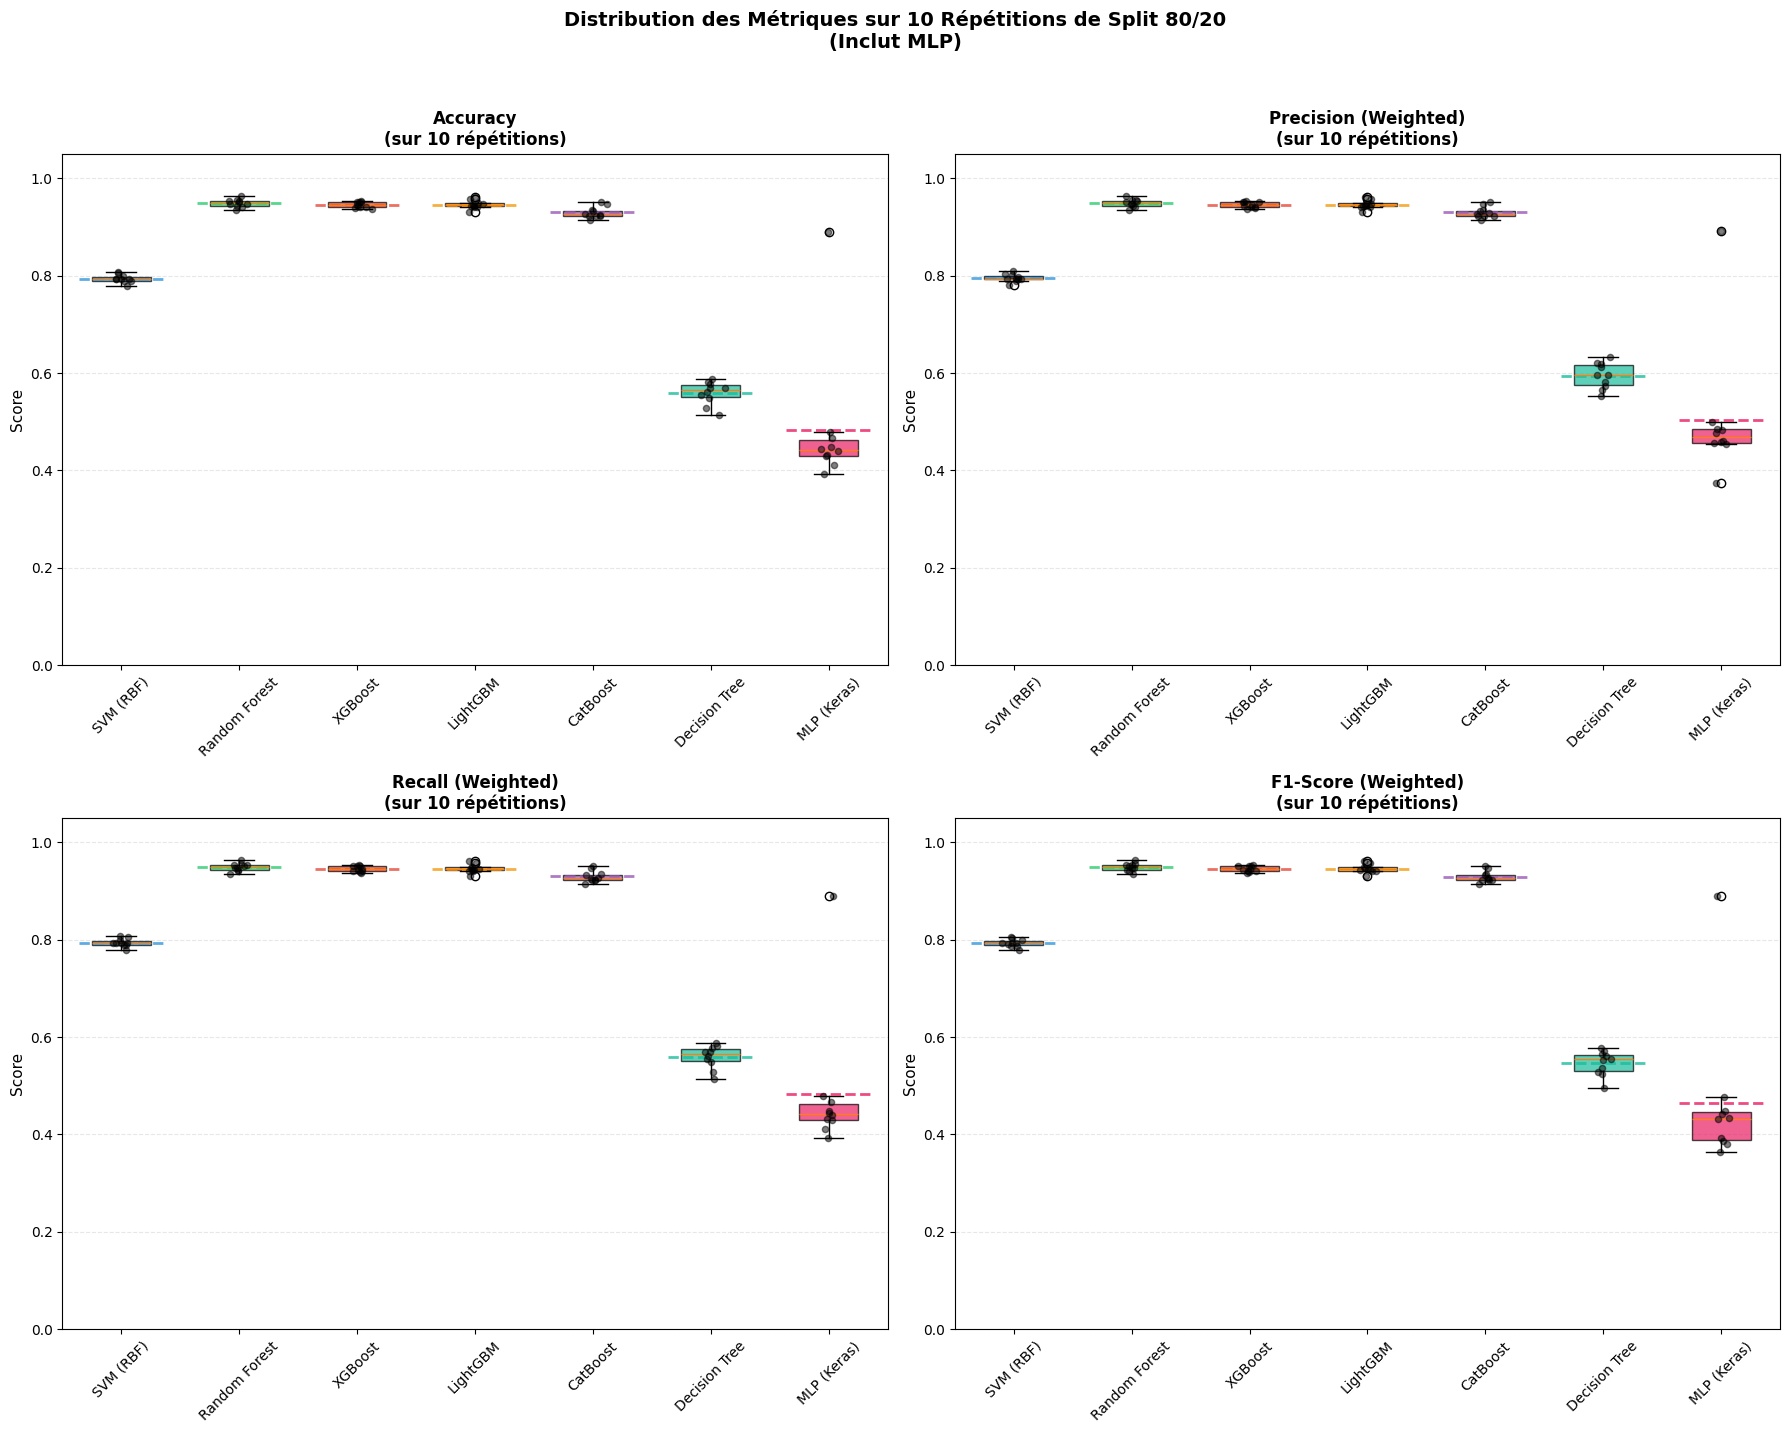

✓ Graphique sauvegardé sous 'metrics_distribution_boxplots.png'


In [18]:
# Visualisation des distributions des métriques avec Boxplots

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
metric_labels = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']

# Couleurs pour tous les modèles (7 modèles)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e91e63']
n_models = len(all_results)

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx // 2, idx % 2]
    
    # Préparer les données pour le boxplot
    data_to_plot = [all_results[model][metric] for model in all_results.keys()]
    
    # Créer le boxplot
    bp = ax.boxplot(data_to_plot, labels=list(all_results.keys()), patch_artist=True)
    
    # Colorier les boxes
    for i, (patch, color) in enumerate(zip(bp['boxes'], colors[:n_models])):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Ajouter les points individuels (scatter)
    for i, (model, values) in enumerate([(m, all_results[m][metric]) for m in all_results.keys()]):
        x = np.random.normal(i + 1, 0.04, size=len(values))
        ax.scatter(x, values, alpha=0.5, color='black', s=20, zorder=3)
    
    ax.set_title(f'{label}\n(sur {N_SPLITS} répétitions)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    
    # Ajouter les moyennes sur le graphique (adapté pour n modèles)
    for i, model in enumerate(all_results.keys()):
        mean_val = np.mean(all_results[model][metric])
        ax.axhline(y=mean_val, xmin=(i)/n_models + 0.02, xmax=(i+1)/n_models - 0.02, 
                   color=colors[i % len(colors)], linestyle='--', linewidth=2, alpha=0.8)

plt.suptitle(f'Distribution des Métriques sur {N_SPLITS} Répétitions de Split 80/20\n(Inclut MLP)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("metrics_distribution_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé sous 'metrics_distribution_boxplots.png'")

### Étape 5 : Matrices de Confusion

📊 Matrices de confusion accumulées sur 10 splits (normalisées en %)


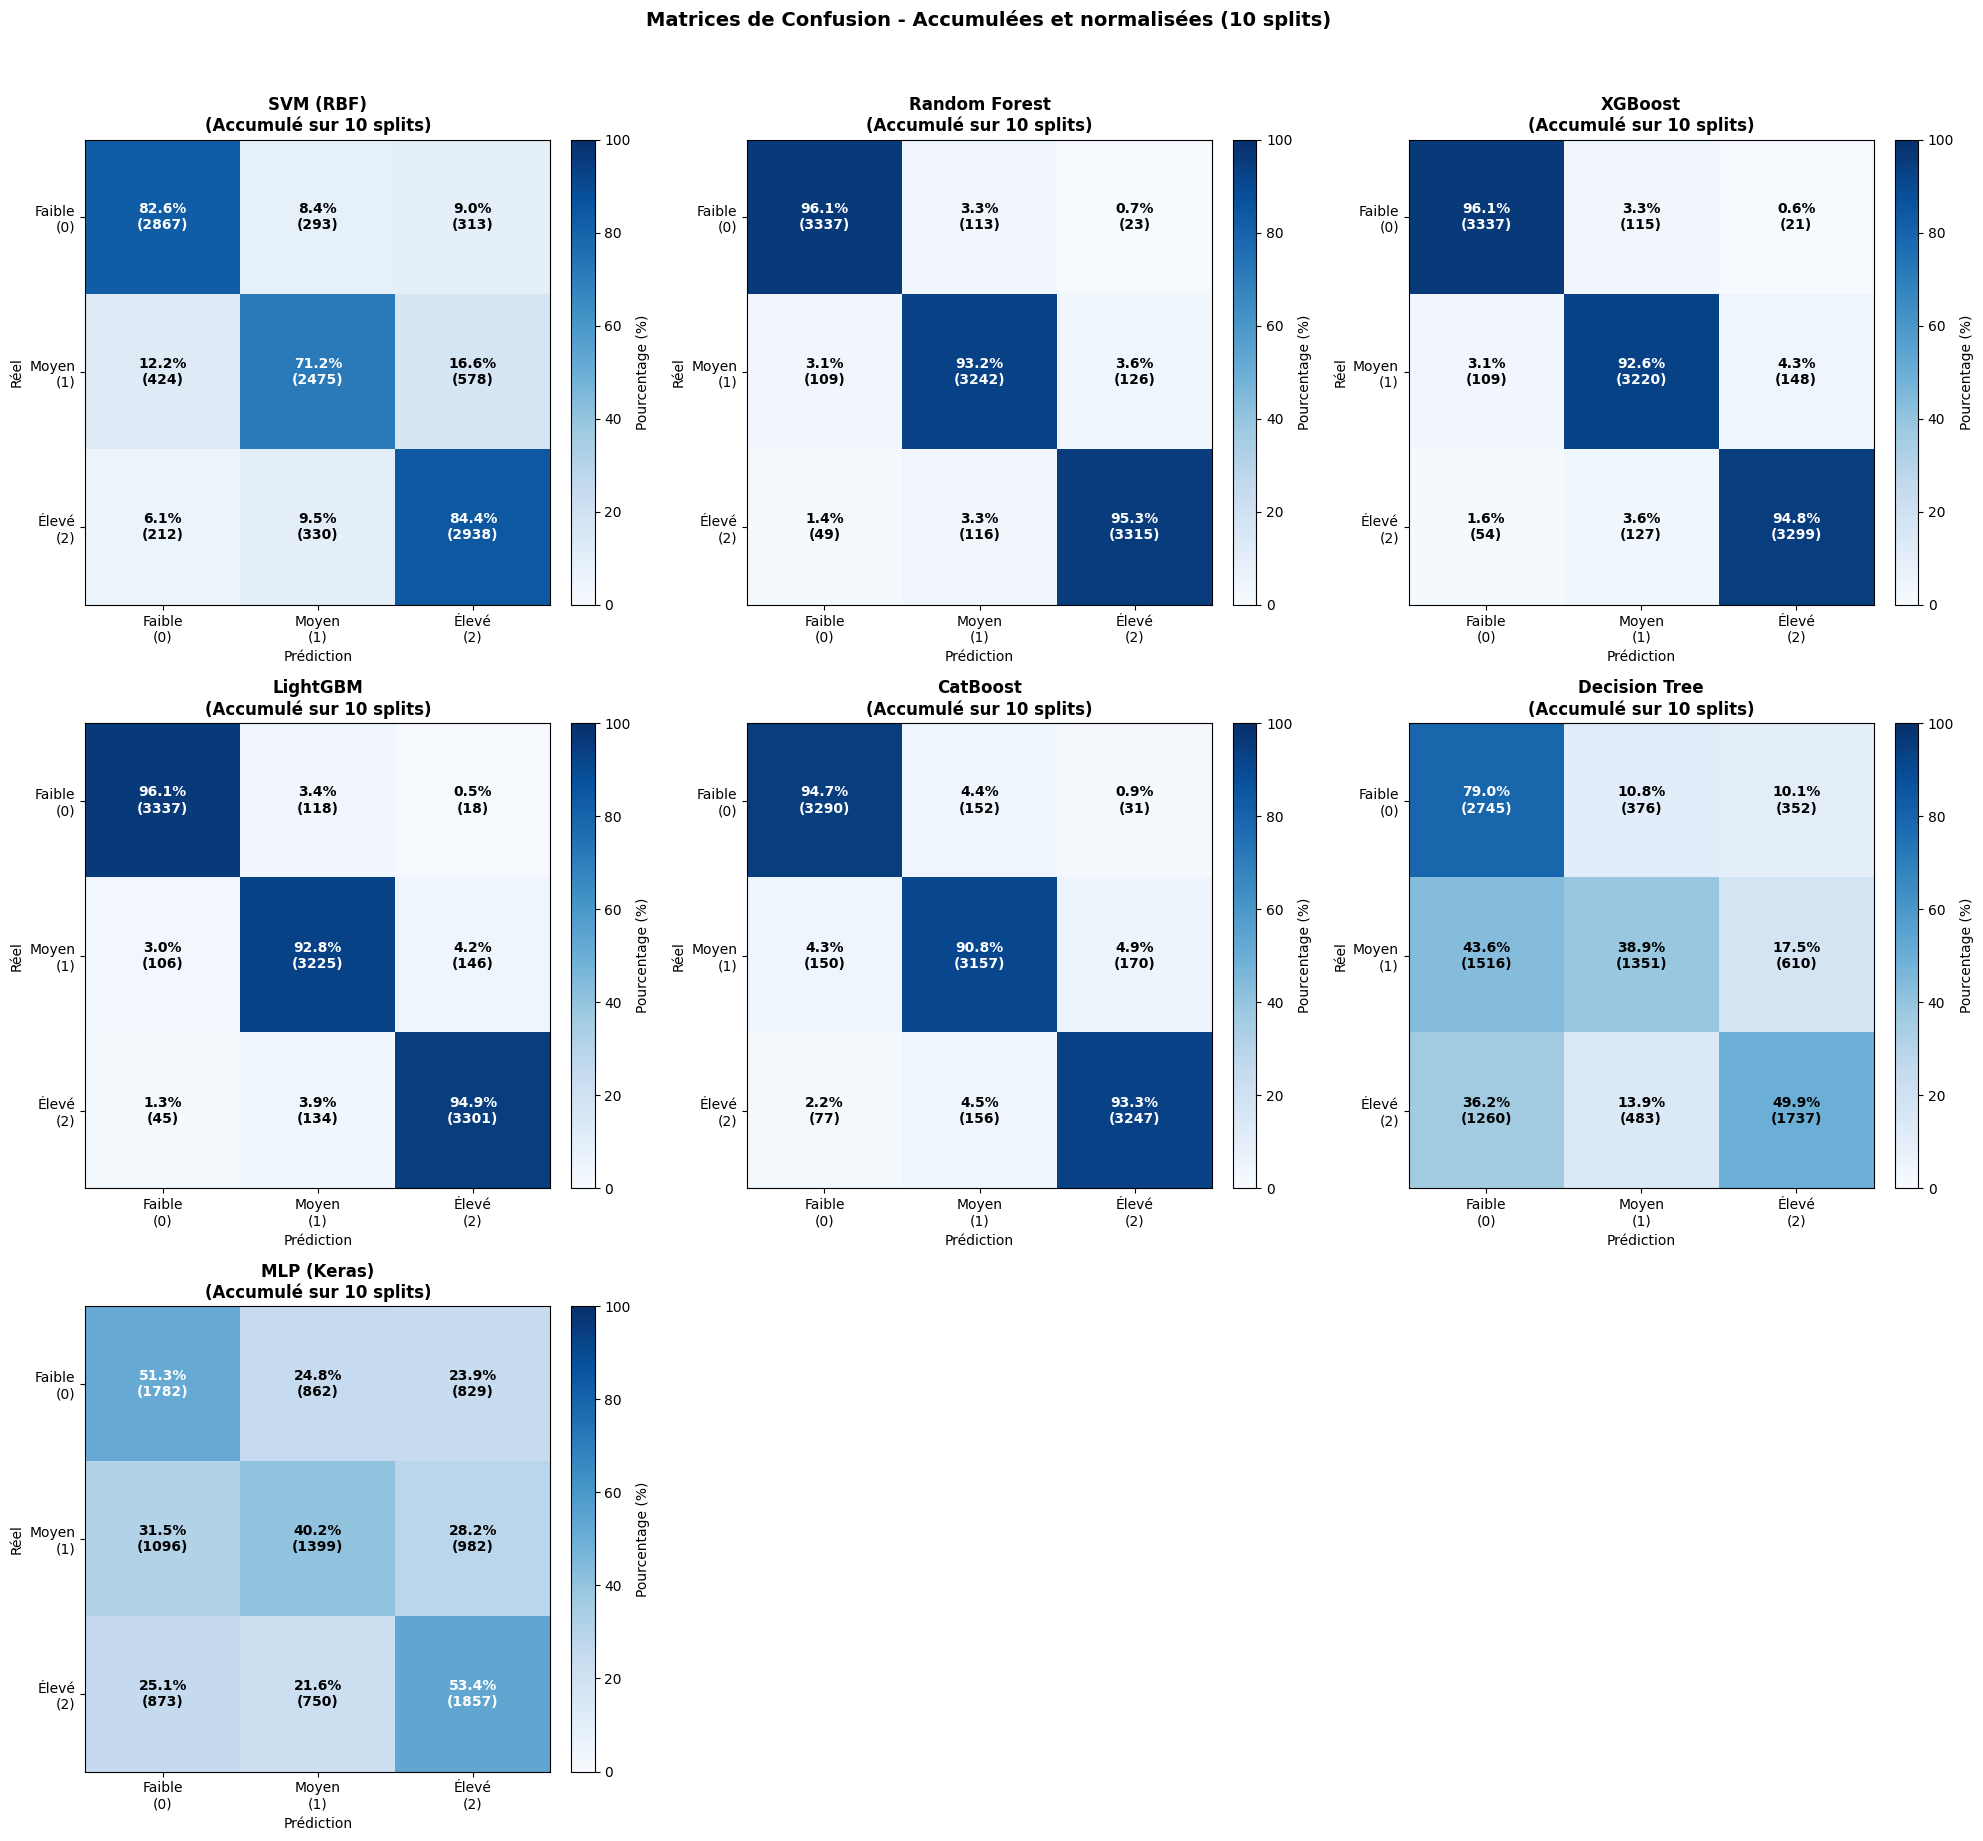


✓ Matrices de confusion affichées (Accumulées et normalisées (10 splits))
✓ Graphique sauvegardé sous 'confusion_matrices.png'


In [19]:
# ============================================================================
# MATRICES DE CONFUSION
# - Si N_SPLITS = 1 : Affichage des valeurs exactes (comme avant)
# - Si N_SPLITS > 1 : Affichage de la matrice accumulée normalisée en %
# ============================================================================

n_models = len(results_with_smote)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = axes.flatten()

# Labels pour les 3 classes
display_labels = ['Faible\n(0)', 'Moyen\n(1)', 'Élevé\n(2)']

if N_SPLITS == 1:
    # ========== CAS N_SPLITS = 1 : Valeurs exactes ==========
    print("📊 Matrices de confusion (valeurs exactes - 1 split)")
    print("="*80)
    
    for idx, (model_name, results) in enumerate(results_with_smote.items()):
        y_pred = results['y_pred']
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=display_labels
        )
        disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
        axes[idx].set_title(f'{model_name}\n(Valeurs exactes)', 
                            fontsize=12, fontweight='bold')
        axes[idx].grid(False)
    
    mode_text = "Valeurs exactes (1 split)"

else:
    # ========== CAS N_SPLITS > 1 : Matrice accumulée normalisée ==========
    print(f"📊 Matrices de confusion accumulées sur {N_SPLITS} splits (normalisées en %)")
    print("="*80)
    
    for idx, model_name in enumerate(results_with_smote.keys()):
        # Accumuler toutes les matrices de confusion
        accumulated_cm = np.zeros((3, 3), dtype=np.float64)
        
        for cm in all_confusion_matrices[model_name]:
            accumulated_cm += cm
        
        # Normaliser par ligne (pour obtenir des pourcentages par classe réelle)
        row_sums = accumulated_cm.sum(axis=1, keepdims=True)
        # Éviter division par zéro
        row_sums = np.where(row_sums == 0, 1, row_sums)
        normalized_cm = (accumulated_cm / row_sums) * 100
        
        # Créer une annotation personnalisée avec % et compte brut
        annot = np.empty_like(normalized_cm, dtype=object)
        for i in range(3):
            for j in range(3):
                pct = normalized_cm[i, j]
                count = int(accumulated_cm[i, j])
                annot[i, j] = f'{pct:.1f}%\n({count})'
        
        # Affichage avec heatmap personnalisée (car ConfusionMatrixDisplay ne supporte pas bien les %)
        im = axes[idx].imshow(normalized_cm, cmap='Blues', vmin=0, vmax=100)
        
        # Ajouter les annotations
        for i in range(3):
            for j in range(3):
                text_color = 'white' if normalized_cm[i, j] > 50 else 'black'
                axes[idx].text(j, i, annot[i, j], ha='center', va='center', 
                              fontsize=10, color=text_color, fontweight='bold')
        
        # Configuration des axes
        axes[idx].set_xticks(range(3))
        axes[idx].set_yticks(range(3))
        axes[idx].set_xticklabels(display_labels)
        axes[idx].set_yticklabels(display_labels)
        axes[idx].set_xlabel('Prédiction')
        axes[idx].set_ylabel('Réel')
        axes[idx].set_title(f'{model_name}\n(Accumulé sur {N_SPLITS} splits)', 
                            fontsize=12, fontweight='bold')
        axes[idx].grid(False)
        
        # Ajouter une colorbar
        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.set_label('Pourcentage (%)')
    
    mode_text = f"Accumulées et normalisées ({N_SPLITS} splits)"

# Masquer les axes vides
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Matrices de Confusion - {mode_text}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Matrices de confusion affichées ({mode_text})")
print("✓ Graphique sauvegardé sous 'confusion_matrices.png'")
print("="*80)

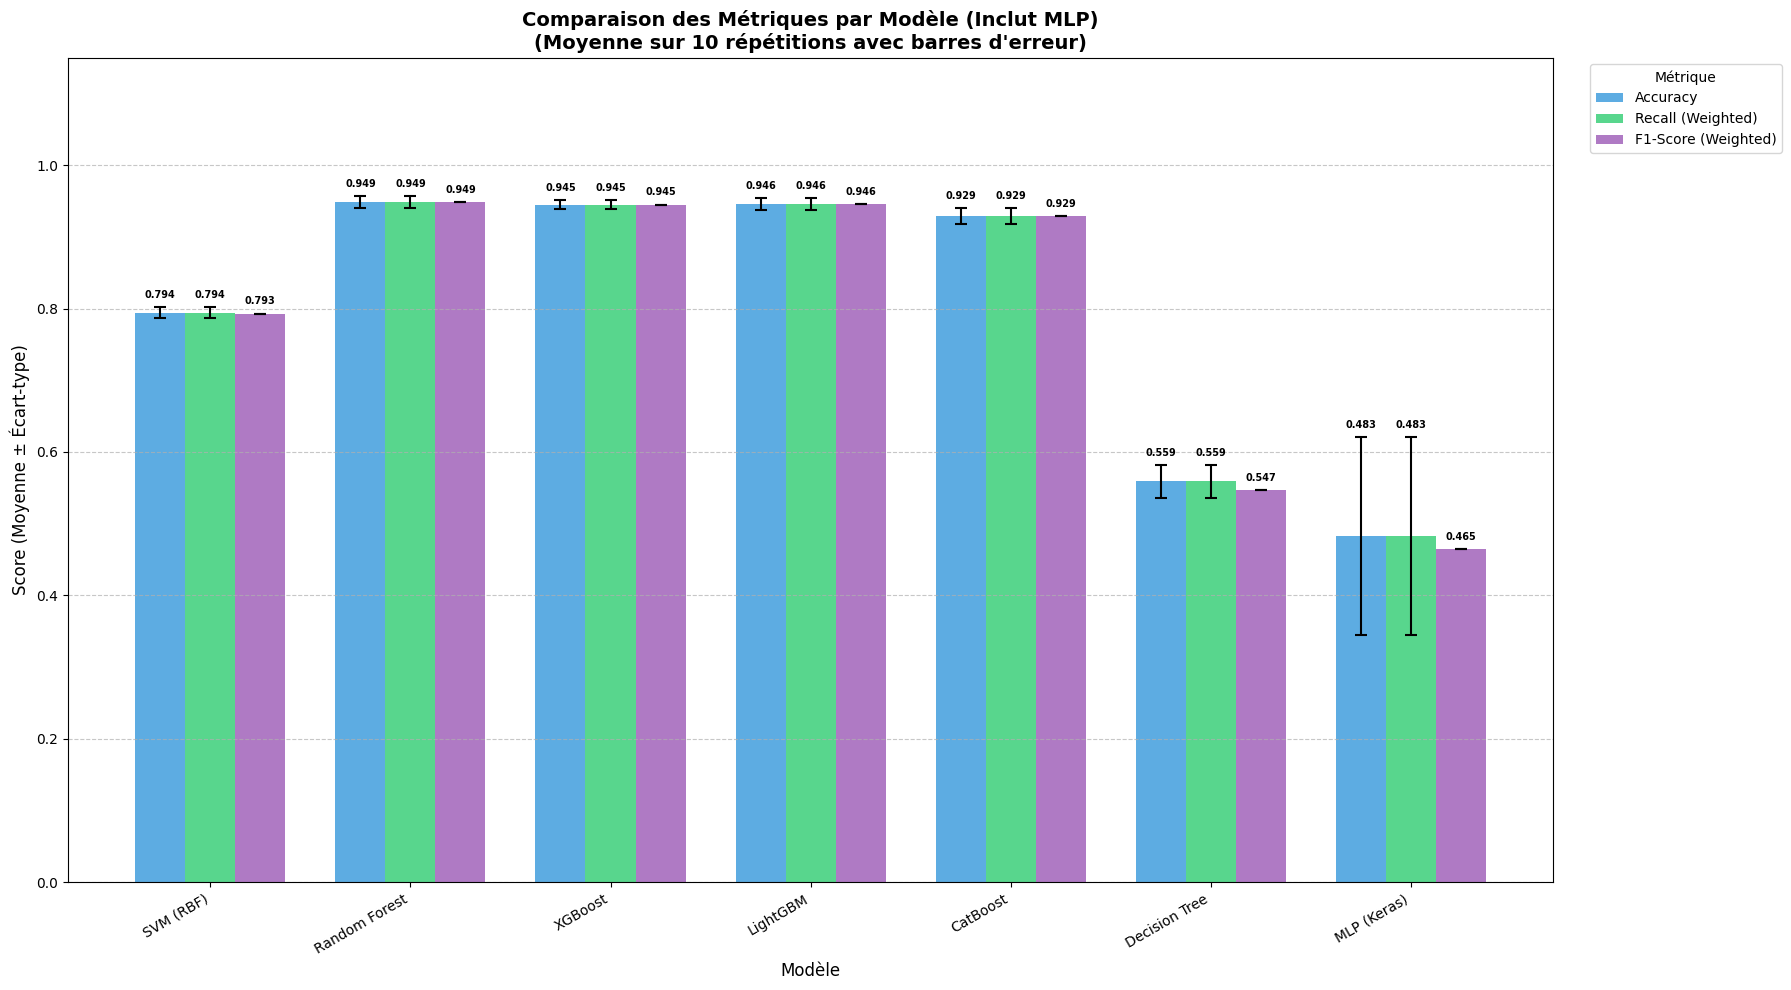

Graphique de comparaison avec écart-type généré et sauvegardé sous 'model_metrics_comparison_with_std.png'


In [20]:
# Graphique comparatif avec barres d'erreur (écart-type)

# Préparer les données avec statistiques
data_list = []
for model_name in all_results.keys():
    data_list.append({
        'Modèle': model_name,
        'Accuracy': np.mean(all_results[model_name]['accuracy']),
        'Accuracy_std': np.std(all_results[model_name]['accuracy']),
        'Recall (Weighted)': np.mean(all_results[model_name]['recall_weighted']),
        'Recall_std': np.std(all_results[model_name]['recall_weighted']),
        'F1-Score (Weighted)': np.mean(all_results[model_name]['f1_weighted']),
        'F1_std': np.std(all_results[model_name]['f1_weighted'])
    })

df_results = pd.DataFrame(data_list)

# Préparer les données pour le graphique
metrics = ['Accuracy', 'Recall (Weighted)', 'F1-Score (Weighted)']
x = np.arange(len(df_results['Modèle']))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 10))

# Créer les barres avec barres d'erreur
colors = ['#3498db', '#2ecc71', '#9b59b6']
for i, metric in enumerate(metrics):
    std_col = metric.split(' ')[0] + '_std'
    if std_col not in df_results.columns:
        std_col = metric.replace(' (Weighted)', '') + '_std'
    
    means = df_results[metric]
    stds = df_results.get(std_col, [0]*len(means))
    
    bars = ax.bar(x + i*width, means, width, label=metric, color=colors[i], alpha=0.8)
    ax.errorbar(x + i*width, means, yerr=stds, fmt='none', color='black', capsize=4, capthick=1.5)
    
    # Ajouter les valeurs sur les barres (ajusté pour plus de modèles)
    for j, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax.annotate(f'{mean:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height + std + 0.01),
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_ylabel('Score (Moyenne ± Écart-type)', fontsize=12)
ax.set_xlabel('Modèle', fontsize=12)
ax.set_title(f'Comparaison des Métriques par Modèle (Inclut MLP)\n(Moyenne sur {N_SPLITS} répétitions avec barres d\'erreur)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(df_results['Modèle'], rotation=30, ha='right')
ax.legend(title='Métrique', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("model_metrics_comparison_with_std.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Graphique de comparaison avec écart-type généré et sauvegardé sous 'model_metrics_comparison_with_std.png'")

## Étape 6 : Analyse de l'Importance des Features

Maintenant, nous pouvons voir quels facteurs (économiques, environnementaux, etc.) ont le plus d'influence sur la prédiction du taux de BPCO.

In [21]:
# ============================================================================
# ANALYSE DES IMPORTANCES ACCUMULÉES SUR TOUTES LES ITÉRATIONS
# AVEC FILTRAGE PAR SEUIL F1-SCORE
# ============================================================================

print("="*100)
print(f"📊 ANALYSE DES IMPORTANCES DES FEATURES SUR {N_SPLITS} ITÉRATIONS")
print(f"⚠️  SEUIL F1-SCORE APPLIQUÉ : {F1_THRESHOLD:.2f}")
print("="*100)

# Créer un DataFrame consolidé avec toutes les importances
# FILTRE : Seuls les modèles/splits avec F1 >= F1_THRESHOLD sont inclus
all_importance_records = []
excluded_count = 0
included_count = 0

for model_name, importance_list in all_feature_importances.items():
    for split_idx, data in enumerate(importance_list):
        # Extraire les importances et le F1-score
        importances = data['importances']
        f1_value = data['f1_score']
        
        # FILTRE : Vérifier si le F1-score est au-dessus du seuil
        if f1_value < F1_THRESHOLD:
            excluded_count += 1
            continue  # Ignorer cette itération
        
        included_count += 1
        
        # Normaliser en pourcentages
        total = importances.sum()
        if total > 0:
            importances_pct = (importances / total) * 100
        else:
            importances_pct = importances
        
        for feat_idx, (feat_name, imp_pct) in enumerate(zip(feature_names, importances_pct)):
            all_importance_records.append({
                'Modèle': model_name,
                'Split': split_idx,
                'Feature': feat_name,
                'Importance (%)': imp_pct,
                'Importance_raw': importances[feat_idx],
                'F1_score': f1_value  # Stocker le F1-score pour référence
            })

df_all_importances = pd.DataFrame(all_importance_records)

print(f"\n📋 RÉSUMÉ DU FILTRAGE :")
print(f"   Itérations incluses  : {included_count} (F1 >= {F1_THRESHOLD:.2f})")
print(f"   Itérations exclues   : {excluded_count} (F1 < {F1_THRESHOLD:.2f})")
print(f"   Taux d'inclusion     : {included_count / (included_count + excluded_count) * 100:.1f}%")

if included_count == 0:
    print(f"\n❌ ERREUR : Aucune itération n'a un F1 >= {F1_THRESHOLD:.2f}")
    print(f"   Réduisez le seuil F1_THRESHOLD ou vérifiez vos modèles.")
else:
    print(f"\n✓ DataFrame créé avec {len(df_all_importances)} enregistrements")
    
    # Afficher les modèles exclus/inclus
    print(f"\n📊 Détail par modèle :")
    for model_name in all_feature_importances.keys():
        model_f1_scores = [d['f1_score'] for d in all_feature_importances[model_name]]
        included = sum(1 for f1 in model_f1_scores if f1 >= F1_THRESHOLD)
        excluded = sum(1 for f1 in model_f1_scores if f1 < F1_THRESHOLD)
        avg_f1 = np.mean(model_f1_scores)
        status = "✓" if included > 0 else "✗"
        print(f"   {status} {model_name}: {included}/{len(model_f1_scores)} splits inclus (F1 moy: {avg_f1:.4f})")

# ============================================================================
# STATISTIQUES AGRÉGÉES PAR FEATURE ET PAR MODÈLE
# ============================================================================

if included_count > 0:
    print(f"\n{'='*100}")
    print("📈 STATISTIQUES D'IMPORTANCE PAR FEATURE (modèles avec F1 >= seuil)")
    print("="*100)

    # Agréger par feature (tous modèles confondus)
    feature_stats = df_all_importances.groupby('Feature').agg({
        'Importance (%)': ['mean', 'std', 'min', 'max', 'count']
    }).round(4)
    feature_stats.columns = ['Moyenne (%)', 'Écart-type', 'Min', 'Max', 'Nb observations']
    feature_stats = feature_stats.sort_values('Moyenne (%)', ascending=False)

    print("\n🔝 Top 20 Features (importance moyenne sur modèles qualifiés) :")
    print(feature_stats.head(20).to_string())

    # ============================================================================
    # FRÉQUENCE D'APPARITION DANS LE TOP 10
    # ============================================================================

    print(f"\n{'='*100}")
    print("🏆 FRÉQUENCE D'APPARITION DANS LE TOP 10 (modèles avec F1 >= seuil)")
    print("="*100)

    # Pour chaque modèle et split qualifié, identifier les top 10 features
    top_n = 10
    top_features_count = {}

    # Compter les itérations qualifiées
    qualified_iterations = 0
    for model_name in all_feature_importances.keys():
        model_data = df_all_importances[df_all_importances['Modèle'] == model_name]
        unique_splits = model_data['Split'].unique()
        
        for split_idx in unique_splits:
            split_data = model_data[model_data['Split'] == split_idx]
            if len(split_data) == 0:
                continue
            
            qualified_iterations += 1
            top_features = split_data.nlargest(top_n, 'Importance (%)')['Feature'].tolist()
            
            for feat in top_features:
                if feat not in top_features_count:
                    top_features_count[feat] = 0
                top_features_count[feat] += 1

    # Créer un DataFrame avec la fréquence
    total_iterations = qualified_iterations
    df_frequency = pd.DataFrame([
        {'Feature': feat, 'Fréquence Top 10': count, 
         'Fréquence (%)': (count / total_iterations) * 100 if total_iterations > 0 else 0}
        for feat, count in top_features_count.items()
    ]).sort_values('Fréquence Top 10', ascending=False)

    print(f"\nTotal d'itérations qualifiées : {total_iterations}")
    print(f"\n🔝 Top 15 Features les plus fréquentes dans le Top 10 :")
    print(df_frequency.head(15).to_string(index=False))

    # ============================================================================
    # STATISTIQUES PAR MODÈLE
    # ============================================================================

    print(f"\n{'='*100}")
    print("📊 IMPORTANCE MOYENNE PAR MODÈLE (Top 10 features)")
    print("="*100)

    # Créer un pivot pour comparer les modèles
    feature_importance_by_model = df_all_importances.groupby(['Modèle', 'Feature'])['Importance (%)'].mean().reset_index()
    pivot_importance = feature_importance_by_model.pivot(index='Feature', columns='Modèle', values='Importance (%)')

    # Calculer la moyenne globale pour trier
    pivot_importance['Moyenne Globale'] = pivot_importance.mean(axis=1)
    pivot_importance = pivot_importance.sort_values('Moyenne Globale', ascending=False)

    print("\n🔝 Top 10 Features avec importance par modèle (modèles qualifiés) :")
    print(pivot_importance.head(10).round(3).to_string())

    # Sauvegarder le pivot dans une variable pour visualisation
    feature_importances_pivot = pivot_importance.copy()
else:
    print("\n⚠️ Impossible de calculer les statistiques - aucune itération qualifiée")

📊 ANALYSE DES IMPORTANCES DES FEATURES SUR 10 ITÉRATIONS
⚠️  SEUIL F1-SCORE APPLIQUÉ : 0.70

📋 RÉSUMÉ DU FILTRAGE :
   Itérations incluses  : 51 (F1 >= 0.70)
   Itérations exclues   : 19 (F1 < 0.70)
   Taux d'inclusion     : 72.9%

✓ DataFrame créé avec 1734 enregistrements

📊 Détail par modèle :
   ✓ SVM (RBF): 10/10 splits inclus (F1 moy: 0.7929)
   ✓ Random Forest: 10/10 splits inclus (F1 moy: 0.9486)
   ✓ XGBoost: 10/10 splits inclus (F1 moy: 0.9449)
   ✓ LightGBM: 10/10 splits inclus (F1 moy: 0.9456)
   ✓ CatBoost: 10/10 splits inclus (F1 moy: 0.9294)
   ✗ Decision Tree: 0/10 splits inclus (F1 moy: 0.5465)
   ✓ MLP (Keras): 1/10 splits inclus (F1 moy: 0.4646)

📈 STATISTIQUES D'IMPORTANCE PAR FEATURE (modèles avec F1 >= seuil)

🔝 Top 20 Features (importance moyenne sur modèles qualifiés) :
                                                                      Moyenne (%)  Écart-type     Min     Max  Nb observations
Feature                                                             

/tmp/ipykernel_1948556/2588123784.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot([boxplot_data[boxplot_data['Feature'] == feat]['Importance (%)'].values


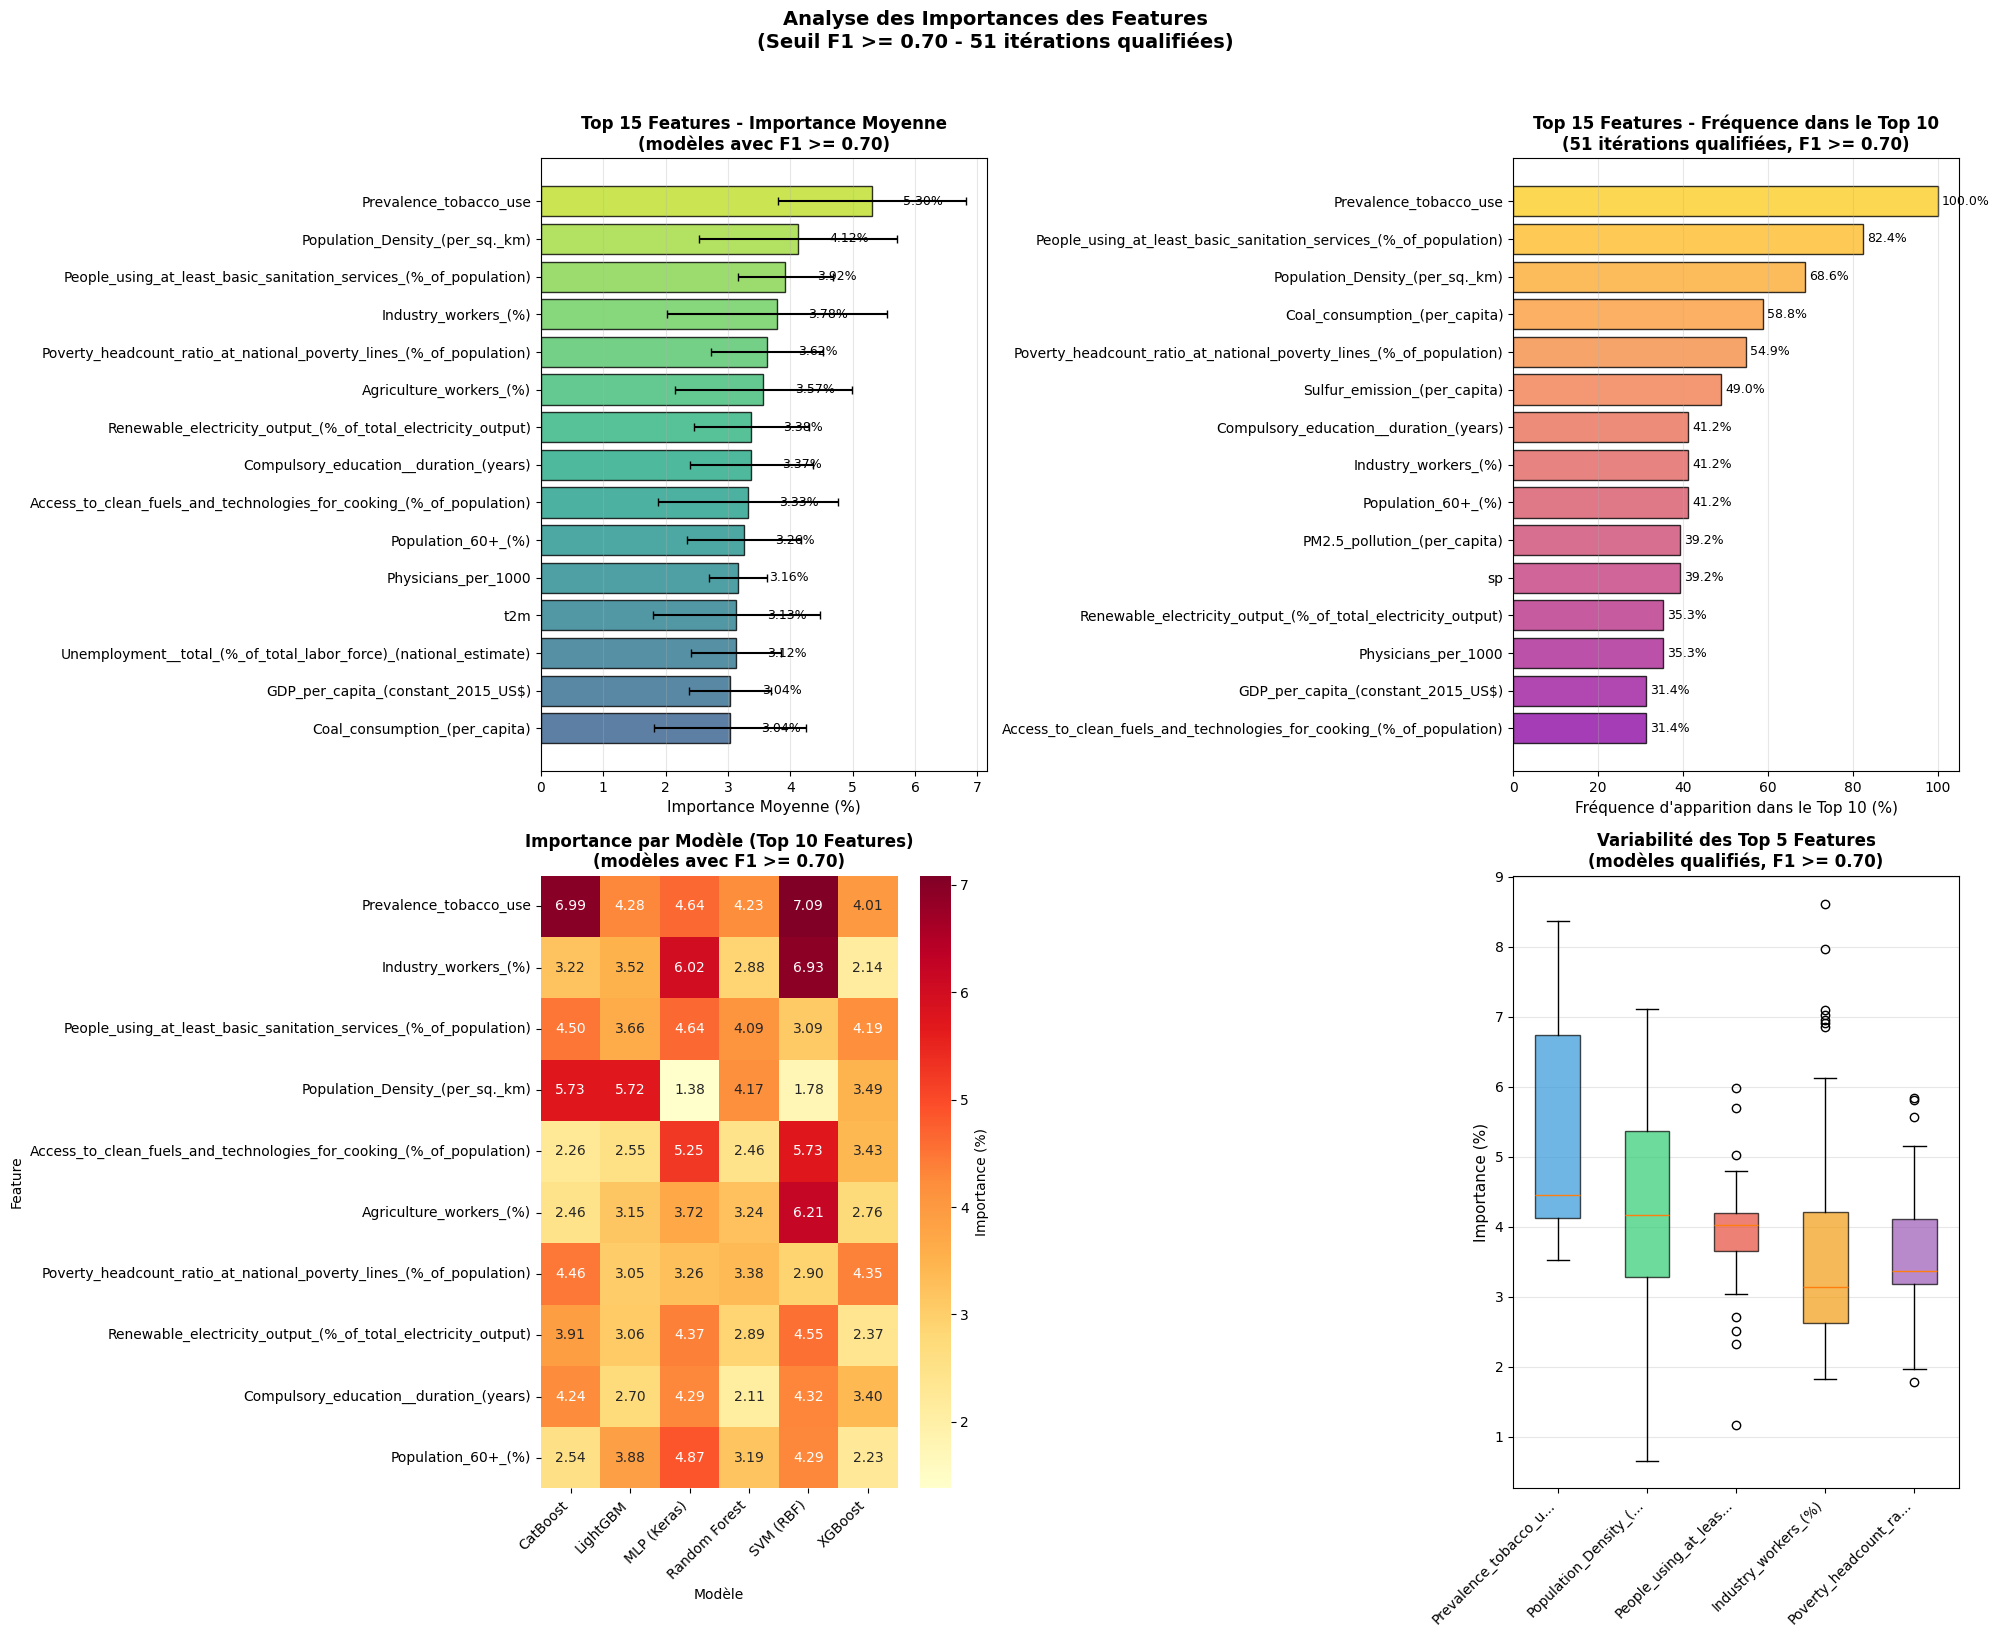

✓ Graphique sauvegardé sous 'feature_importance_analysis_aggregated.png'


In [22]:
# ============================================================================
# VISUALISATION : Importance moyenne avec barres d'erreur (Top 15)
# UNIQUEMENT SI DES ITÉRATIONS ONT ÉTÉ QUALIFIÉES
# ============================================================================

if included_count > 0:
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    # --- Graphique 1 : Top 15 features (moyenne globale avec écart-type) ---
    ax1 = axes[0, 0]
    top15_global = feature_stats.head(15).copy()
    top15_global = top15_global.sort_values('Moyenne (%)', ascending=True)

    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top15_global)))
    bars = ax1.barh(top15_global.index, top15_global['Moyenne (%)'], 
                    xerr=top15_global['Écart-type'], color=colors, alpha=0.8,
                    edgecolor='black', capsize=3)
    ax1.set_xlabel('Importance Moyenne (%)', fontsize=11)
    ax1.set_title(f'Top 15 Features - Importance Moyenne\n(modèles avec F1 >= {F1_THRESHOLD:.2f})', 
                  fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    # Ajouter valeurs
    for bar, mean_val in zip(bars, top15_global['Moyenne (%)']):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{mean_val:.2f}%', va='center', fontsize=9)

    # --- Graphique 2 : Fréquence d'apparition dans le Top 10 ---
    ax2 = axes[0, 1]
    top15_freq = df_frequency.head(15).copy()
    top15_freq = top15_freq.sort_values('Fréquence (%)', ascending=True)

    colors_freq = plt.cm.plasma(np.linspace(0.3, 0.9, len(top15_freq)))
    bars2 = ax2.barh(top15_freq['Feature'], top15_freq['Fréquence (%)'], 
                     color=colors_freq, alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Fréquence d\'apparition dans le Top 10 (%)', fontsize=11)
    ax2.set_title(f'Top 15 Features - Fréquence dans le Top 10\n({total_iterations} itérations qualifiées, F1 >= {F1_THRESHOLD:.2f})', 
                  fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

    for bar, freq_val in zip(bars2, top15_freq['Fréquence (%)']):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{freq_val:.1f}%', va='center', fontsize=9)

    # --- Graphique 3 : Heatmap des importances par modèle ---
    ax3 = axes[1, 0]
    top10_heatmap = feature_importances_pivot.drop(columns=['Moyenne Globale']).head(10)
    sns.heatmap(top10_heatmap, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax3,
                cbar_kws={'label': 'Importance (%)'})
    ax3.set_title(f'Importance par Modèle (Top 10 Features)\n(modèles avec F1 >= {F1_THRESHOLD:.2f})', 
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Modèle')
    ax3.set_ylabel('Feature')
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

    # --- Graphique 4 : Boxplot de la variabilité des importances ---
    ax4 = axes[1, 1]
    top5_features = feature_stats.head(5).index.tolist()
    boxplot_data = df_all_importances[df_all_importances['Feature'].isin(top5_features)]

    box_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
    bp = ax4.boxplot([boxplot_data[boxplot_data['Feature'] == feat]['Importance (%)'].values 
                      for feat in top5_features],
                     labels=[f[:20] + '...' if len(f) > 20 else f for f in top5_features],
                     patch_artist=True)

    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax4.set_ylabel('Importance (%)', fontsize=11)
    ax4.set_title(f'Variabilité des Top 5 Features\n(modèles qualifiés, F1 >= {F1_THRESHOLD:.2f})', 
                  fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

    plt.suptitle(f'Analyse des Importances des Features\n(Seuil F1 >= {F1_THRESHOLD:.2f} - {included_count} itérations qualifiées)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("feature_importance_analysis_aggregated.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Graphique sauvegardé sous 'feature_importance_analysis_aggregated.png'")
else:
    print("⚠️ Aucun graphique généré - pas d'itérations qualifiées")

📋 TABLEAU RÉCAPITULATIF FINAL - FEATURES LES PLUS IMPORTANTES
⚠️  Basé sur 51 itérations qualifiées (F1 >= 0.70)

🏆 Top 20 Features (classées par Score Combiné = Fréquence × Importance) :
----------------------------------------------------------------------------------------------------
                                                             Feature  Freq. Top 10  Freq. (%)  Imp. Moy. (%)  Écart-type (%)  Score Combiné
                                              Prevalence_tobacco_use            51 100.000000         5.3042          1.5042       5.304200
   People_using_at_least_basic_sanitation_services_(%_of_population)            42  82.352941         3.9212          0.7567       3.229224
                                     Population_Density_(per_sq._km)            35  68.627451         4.1214          1.5935       2.828412
 Poverty_headcount_ratio_at_national_poverty_lines_(%_of_population)            28  54.901961         3.6202          0.8959       1.987561
           

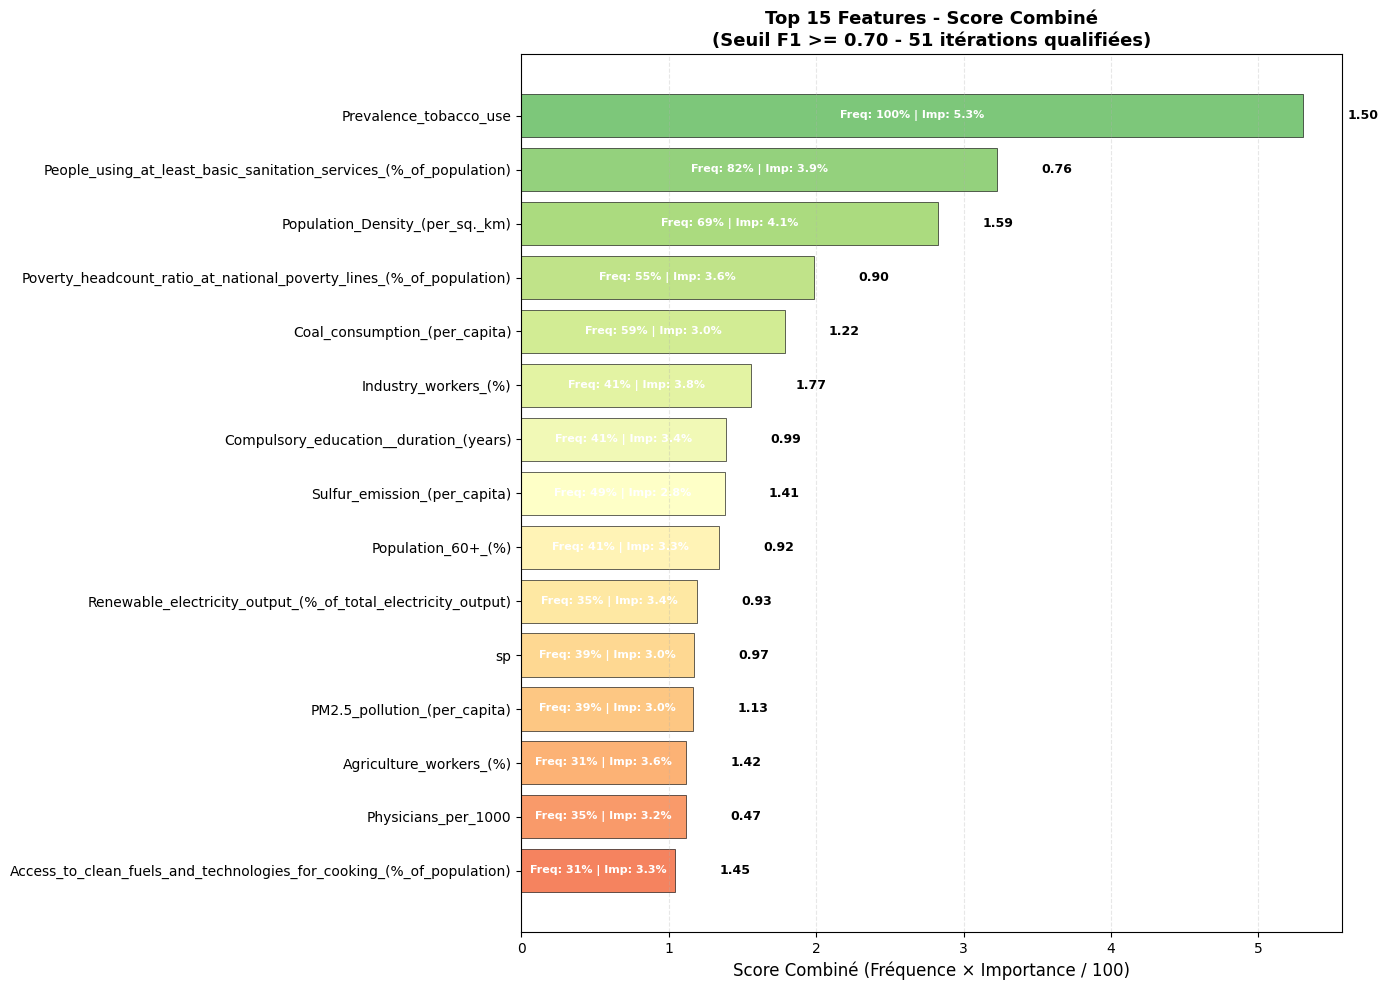


✓ Graphique sauvegardé sous 'feature_importance_combined_score.png'

💾 DataFrame complet exporté : feature_importances_all_iterations_f1_0.70.csv
💾 Récapitulatif exporté : feature_importances_summary_f1_0.70.csv



In [23]:
# ============================================================================
# TABLEAU RÉCAPITULATIF FINAL : FRÉQUENCE + IMPORTANCE MOYENNE
# AVEC INDICATION DU FILTRAGE PAR SEUIL F1
# ============================================================================

if included_count > 0:
    print("="*100)
    print("📋 TABLEAU RÉCAPITULATIF FINAL - FEATURES LES PLUS IMPORTANTES")
    print(f"⚠️  Basé sur {included_count} itérations qualifiées (F1 >= {F1_THRESHOLD:.2f})")
    print("="*100)

    # Fusionner les données de fréquence et d'importance moyenne
    df_final_summary = df_frequency.merge(
        feature_stats[['Moyenne (%)', 'Écart-type']].reset_index(),
        on='Feature',
        how='left'
    )

    # Ajouter un score combiné (fréquence × importance)
    df_final_summary['Score Combiné'] = (
        df_final_summary['Fréquence (%)'] * df_final_summary['Moyenne (%)'] / 100
    )
    df_final_summary = df_final_summary.sort_values('Score Combiné', ascending=False)

    # Renommer les colonnes pour clarté
    df_final_summary = df_final_summary.rename(columns={
        'Fréquence Top 10': 'Freq. Top 10',
        'Fréquence (%)': 'Freq. (%)',
        'Moyenne (%)': 'Imp. Moy. (%)',
        'Écart-type': 'Écart-type (%)'
    })

    print(f"\n🏆 Top 20 Features (classées par Score Combiné = Fréquence × Importance) :")
    print("-" * 100)
    print(df_final_summary.head(20).to_string(index=False))

    # ============================================================================
    # VISUALISATION : Top 15 avec Score Combiné
    # ============================================================================

    fig, ax = plt.subplots(figsize=(14, 10))

    top15_final = df_final_summary.head(15).copy()
    top15_final = top15_final.sort_values('Score Combiné', ascending=True)

    # Barres principales (score combiné)
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top15_final)))
    bars = ax.barh(top15_final['Feature'], top15_final['Score Combiné'], 
                   color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

    # Ajouter les valeurs
    for bar, row in zip(bars, top15_final.itertuples()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{row._5:.2f}', va='center', fontsize=9, fontweight='bold')  # Score Combiné
        ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height()/2,
                f'Freq: {row._3:.0f}% | Imp: {row._4:.1f}%', 
                va='center', ha='center', fontsize=8, color='white', fontweight='bold')

    ax.set_xlabel('Score Combiné (Fréquence × Importance / 100)', fontsize=12)
    ax.set_title(f'Top 15 Features - Score Combiné\n(Seuil F1 >= {F1_THRESHOLD:.2f} - {included_count} itérations qualifiées)', 
                 fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig("feature_importance_combined_score.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Graphique sauvegardé sous 'feature_importance_combined_score.png'")

    # ============================================================================
    # EXPORT DES RÉSULTATS
    # ============================================================================

    # Sauvegarder le DataFrame complet des importances (avec F1-score)
    output_path = f"feature_importances_all_iterations_f1_{F1_THRESHOLD:.2f}.csv"
    df_all_importances.to_csv(output_path, index=False)
    print(f"\n💾 DataFrame complet exporté : {output_path}")

    # Sauvegarder le récapitulatif
    summary_path = f"feature_importances_summary_f1_{F1_THRESHOLD:.2f}.csv"
    df_final_summary.to_csv(summary_path, index=False)
    print(f"💾 Récapitulatif exporté : {summary_path}")

    print("\n" + "="*100)
else:
    print("⚠️ Impossible de générer le récapitulatif - aucune itération qualifiée")
    print(f"   Conseil : Réduisez F1_THRESHOLD (actuellement {F1_THRESHOLD:.2f})")

In [24]:
# Export du DataFrame imputé pour éviter de refaire l'imputation à chaque fois
# L'imputation avec IterativeImputer prend beaucoup de temps

import os

# Créer un dossier pour les données prétraitées si nécessaire
output_dir = "preprocessed_data"
os.makedirs(output_dir, exist_ok=True)

# Définir les chemins de sortie
csv_path = os.path.join(output_dir, f"df_imputed_{folder_name}_{file_name}.csv")
parquet_path = os.path.join(output_dir, f"df_imputed_{folder_name}_{file_name}.parquet")

# Export en CSV
print(f"💾 Export en CSV : {csv_path}")
df_imputed.to_csv(csv_path, index=False)
print(f"✓ Exporté avec succès ({os.path.getsize(csv_path) / 1024:.2f} KB)")

# Export en Parquet (format plus compact et rapide)
print(f"\n💾 Export en Parquet : {parquet_path}")
df_imputed.to_parquet(parquet_path, index=False, engine='pyarrow')
print(f"✓ Exporté avec succès ({os.path.getsize(parquet_path) / 1024:.2f} KB)")

print(f"\n{'='*80}")
print("📌 UTILISATION :")
print("="*80)
print("Pour charger les données prétraitées la prochaine fois :")
print()
print("# Option 1 : CSV")
print(f"df_imputed = pd.read_csv('{csv_path}')")
print()
print("# Option 2 : Parquet (plus rapide et compact)")
print(f"df_imputed = pd.read_parquet('{parquet_path}')")
print()
print("# N'oubliez pas de recharger Y_class et Y_label depuis df original :")
print("df_imputed['Y_class'] = y_class_saved")
print("df_imputed['Y_label'] = y_label_saved")
print("="*80)

💾 Export en CSV : preprocessed_data/df_imputed_9019_COPD_prevalence_rate_s_2.csv
✓ Exporté avec succès (5977.72 KB)

💾 Export en Parquet : preprocessed_data/df_imputed_9019_COPD_prevalence_rate_s_2.parquet
✓ Exporté avec succès (1448.02 KB)

📌 UTILISATION :
Pour charger les données prétraitées la prochaine fois :

# Option 1 : CSV
df_imputed = pd.read_csv('preprocessed_data/df_imputed_9019_COPD_prevalence_rate_s_2.csv')

# Option 2 : Parquet (plus rapide et compact)
df_imputed = pd.read_parquet('preprocessed_data/df_imputed_9019_COPD_prevalence_rate_s_2.parquet')

# N'oubliez pas de recharger Y_class et Y_label depuis df original :
df_imputed['Y_class'] = y_class_saved
df_imputed['Y_label'] = y_label_saved


## 🔍 Analyse SHAP Comparative Multi-Modèles

Cette section implémente une analyse d'interprétabilité SHAP pour comparer les "raisonnements" de différents modèles :
- **Tree-based models** (Random Forest, LightGBM, CatBoost, XGBoost, Decision Tree) → `shap.TreeExplainer`
- **SVM** → `shap.KernelExplainer` avec optimisation (données de fond résumées via kmeans)

⚠️ **Note** : Le SVM utilise `KernelExplainer` qui est plus lent. Pour optimiser, on résume les données de fond avec `shap.kmeans(X_train, 10)`.

In [25]:
# Installation des librairies si nécessaire
# !pip install shap lightgbm --quiet

import shap
import warnings
warnings.filterwarnings('ignore')

# Initialiser JavaScript pour les visualisations SHAP interactives
shap.initjs()

print("✅ SHAP importé avec succès")
print(f"   Version SHAP: {shap.__version__}")

✅ SHAP importé avec succès
   Version SHAP: 0.50.0


In [26]:
# =============================================================================
# ANALYSE SHAP COMPARATIVE MULTI-MODÈLES (avec valeurs du repeated hold-out)
# =============================================================================
# Les valeurs SHAP ont été calculées et accumulées dans la boucle principale.
# Ce code agrège les valeurs SHAP de toutes les itérations qualifiées (F1 >= seuil)
# pour générer des beeswarm plots représentatifs.
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

print("="*100)
print("🔍 ANALYSE SHAP COMPARATIVE MULTI-MODÈLES (Repeated Hold-Out)")
print("="*100)
print(f"\n📊 Modèles SHAP analysés: {', '.join(MODELS_FOR_SHAP)}")
print(f"📈 Nombre de features: {len(feature_names)}")
print(f"🎯 Seuil F1 pour inclusion: {F1_THRESHOLD}")

# Agréger les valeurs SHAP de toutes les itérations qualifiées
aggregated_shap = {}

for model_name in MODELS_FOR_SHAP:
    shap_data_list = all_shap_values[model_name]
    
    if len(shap_data_list) == 0:
        print(f"\n⚠️ {model_name}: Aucune itération qualifiée (F1 < {F1_THRESHOLD})")
        continue
    
    print(f"\n✅ {model_name}: {len(shap_data_list)} itérations qualifiées")
    
    # Déterminer le format des valeurs SHAP (liste ou array 3D pour multi-classe)
    first_shap = shap_data_list[0]['shap_values']
    
    if isinstance(first_shap, list):
        # Format liste : on prend la classe "Élevé" (index 2)
        n_classes = len(first_shap)
        class_idx = 2 if n_classes >= 3 else 1
        
        all_shap_class = []
        all_X_data = []
        
        for item in shap_data_list:
            shap_vals = item['shap_values'][class_idx]
            X_data = item['X_data']
            all_shap_class.append(shap_vals)
            all_X_data.append(X_data if isinstance(X_data, np.ndarray) else X_data)
        
        # Concaténer toutes les valeurs
        concat_shap = np.concatenate(all_shap_class, axis=0)
        concat_X = np.concatenate(all_X_data, axis=0)
        class_info = "Classe 'Élevé' (2)" if class_idx == 2 else "Classe Positive (1)"
        
    elif isinstance(first_shap, np.ndarray):
        if first_shap.ndim == 3:
            # Format array 3D : (n_samples, n_features, n_classes)
            n_classes = first_shap.shape[2]
            class_idx = 2 if n_classes >= 3 else 1
            
            all_shap_class = []
            all_X_data = []
            
            for item in shap_data_list:
                shap_vals = item['shap_values'][:, :, class_idx]
                X_data = item['X_data']
                all_shap_class.append(shap_vals)
                all_X_data.append(X_data if isinstance(X_data, np.ndarray) else X_data)
            
            concat_shap = np.concatenate(all_shap_class, axis=0)
            concat_X = np.concatenate(all_X_data, axis=0)
            class_info = "Classe 'Élevé' (2)" if class_idx == 2 else "Classe Positive (1)"
        else:
            # Format array 2D
            all_shap_vals = [item['shap_values'] for item in shap_data_list]
            all_X_data = [item['X_data'] if isinstance(item['X_data'], np.ndarray) else item['X_data'] 
                          for item in shap_data_list]
            
            concat_shap = np.concatenate(all_shap_vals, axis=0)
            concat_X = np.concatenate(all_X_data, axis=0)
            class_info = "Toutes classes"
    else:
        print(f"   ⚠️ Format non supporté: {type(first_shap)}")
        continue
    
    # Sous-échantillonner si trop de données (pour éviter plots trop denses)
    MAX_SAMPLES_PLOT = 2000
    if concat_shap.shape[0] > MAX_SAMPLES_PLOT:
        indices = np.random.choice(concat_shap.shape[0], MAX_SAMPLES_PLOT, replace=False)
        concat_shap = concat_shap[indices]
        concat_X = concat_X[indices]
        print(f"   📉 Sous-échantillonné à {MAX_SAMPLES_PLOT} points pour visualisation")
    
    aggregated_shap[model_name] = {
        'shap_values': concat_shap,
        'X_data': concat_X,
        'class_info': class_info,
        'n_iterations': len(shap_data_list),
        'total_samples': concat_shap.shape[0]
    }
    
    print(f"   📐 Dimensions agrégées: SHAP {concat_shap.shape}, X {concat_X.shape}")
    print(f"   🎯 {class_info}")

print("\n" + "="*100)
print(f"✅ Agrégation terminée pour {len(aggregated_shap)} modèles")
print("="*100)

🔍 ANALYSE SHAP COMPARATIVE MULTI-MODÈLES (Repeated Hold-Out)

📊 Modèles SHAP analysés: SVM (RBF), Random Forest, XGBoost, LightGBM, CatBoost
📈 Nombre de features: 34
🎯 Seuil F1 pour inclusion: 0.7

✅ SVM (RBF): 10 itérations qualifiées
   📐 Dimensions agrégées: SHAP (500, 34), X (500, 34)
   🎯 Classe 'Élevé' (2)

✅ Random Forest: 10 itérations qualifiées
   📐 Dimensions agrégées: SHAP (500, 34), X (500, 34)
   🎯 Classe 'Élevé' (2)

✅ XGBoost: 10 itérations qualifiées
   📐 Dimensions agrégées: SHAP (500, 34), X (500, 34)
   🎯 Classe 'Élevé' (2)

✅ LightGBM: 10 itérations qualifiées
   📐 Dimensions agrégées: SHAP (500, 34), X (500, 34)
   🎯 Classe 'Élevé' (2)

✅ CatBoost: 10 itérations qualifiées
   📐 Dimensions agrégées: SHAP (500, 34), X (500, 34)
   🎯 Classe 'Élevé' (2)

✅ Agrégation terminée pour 5 modèles


In [27]:
# =============================================================================
# RÉSUMÉ DES VALEURS SHAP AGRÉGÉES
# =============================================================================
# Affiche un résumé des valeurs SHAP accumulées par modèle avant la visualisation

print("="*100)
print("📊 RÉSUMÉ DES VALEURS SHAP AGRÉGÉES (Repeated Hold-Out)")
print("="*100)

if len(aggregated_shap) == 0:
    print("\n❌ Aucun modèle n'a de valeurs SHAP agrégées.")
    print(f"   Vérifiez que les modèles atteignent le seuil F1 ≥ {F1_THRESHOLD}")
else:
    print(f"\n{'Modèle':<20} {'Itérations':>12} {'Échantillons':>14} {'Classe':>20}")
    print("-" * 70)
    
    for model_name, data in aggregated_shap.items():
        print(f"{model_name:<20} {data['n_iterations']:>12} {data['total_samples']:>14} {data['class_info']:>20}")
    
    print("-" * 70)
    print(f"\n✅ Prêt pour la génération des beeswarm plots agrégés")
    print(f"   → Les plots représentent la distribution SHAP sur {N_SPLITS} répétitions")

📊 RÉSUMÉ DES VALEURS SHAP AGRÉGÉES (Repeated Hold-Out)

Modèle                 Itérations   Échantillons               Classe
----------------------------------------------------------------------
SVM (RBF)                      10            500   Classe 'Élevé' (2)
Random Forest                  10            500   Classe 'Élevé' (2)
XGBoost                        10            500   Classe 'Élevé' (2)
LightGBM                       10            500   Classe 'Élevé' (2)
CatBoost                       10            500   Classe 'Élevé' (2)
----------------------------------------------------------------------

✅ Prêt pour la génération des beeswarm plots agrégés
   → Les plots représentent la distribution SHAP sur 10 répétitions


📊 VISUALISATION SHAP - Beeswarm Plots AGRÉGÉS (Repeated Hold-Out)

🎨 Beeswarm AGRÉGÉ pour SVM (RBF)
   📊 10 itérations | 500 échantillons


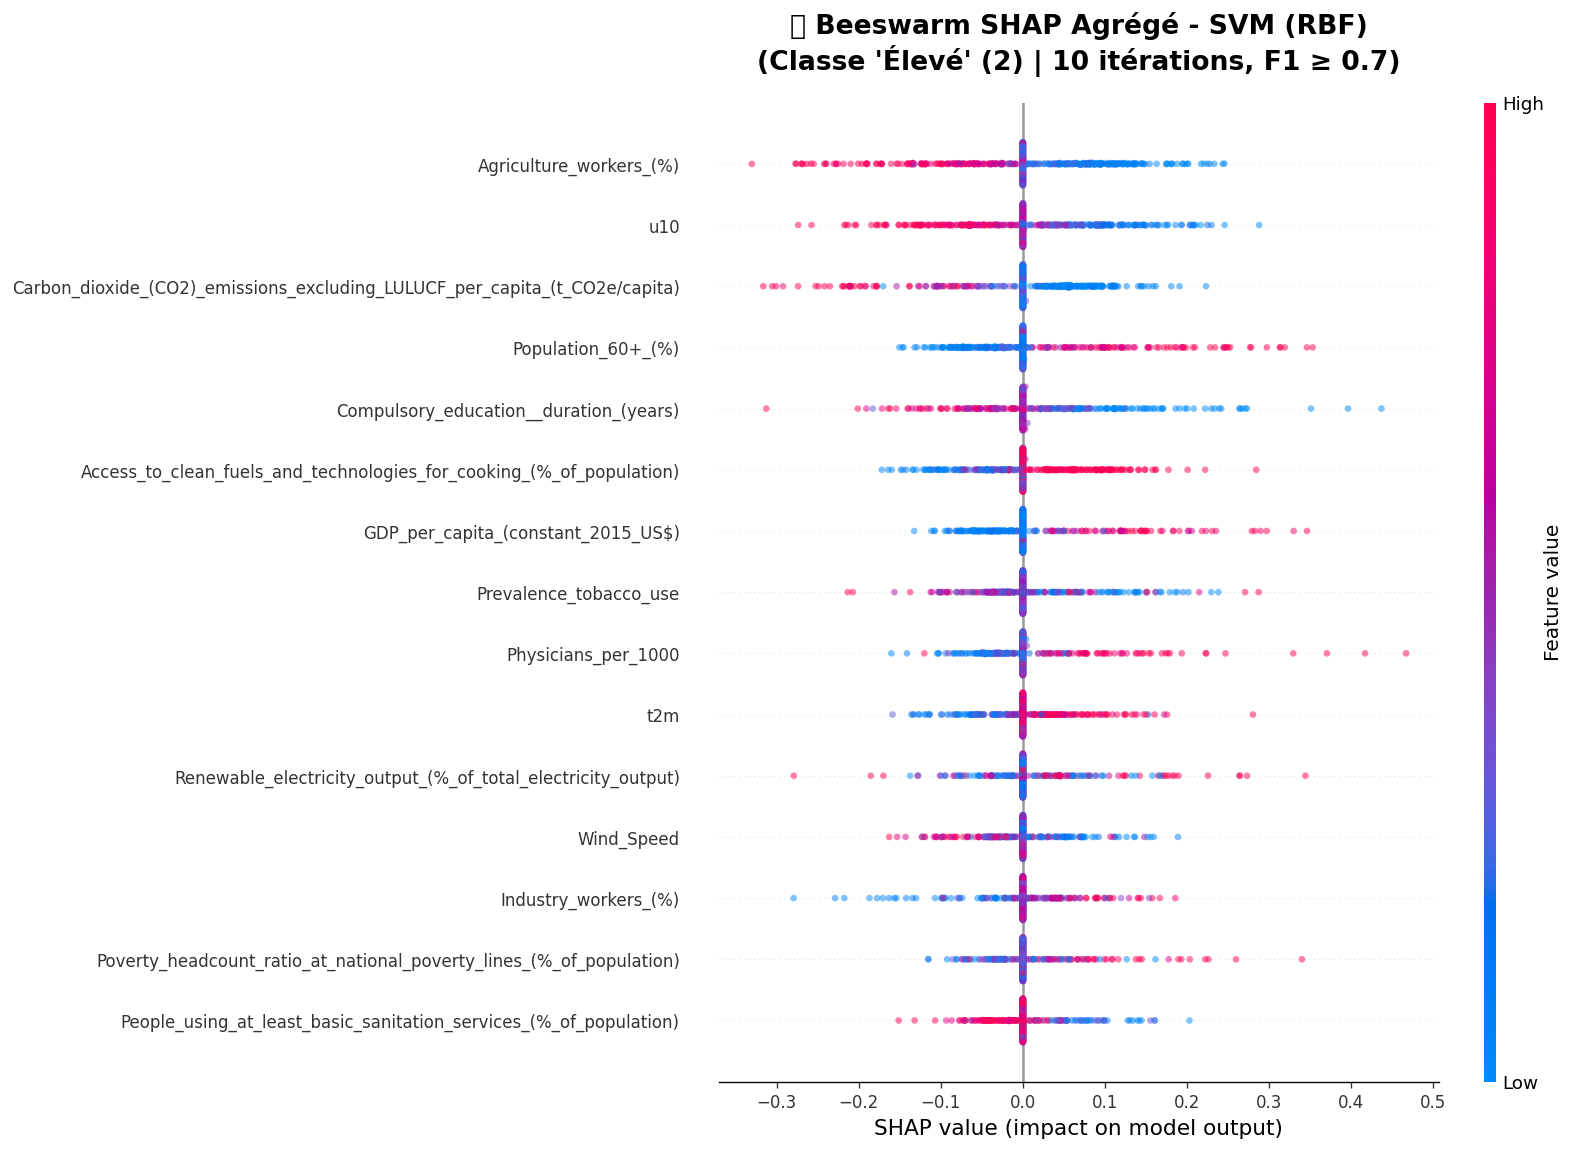

   💾 Sauvegardé: preprocessed_data/shap_beeswarm_aggregated_SVM_RBF.png

🎨 Beeswarm AGRÉGÉ pour Random Forest
   📊 10 itérations | 500 échantillons


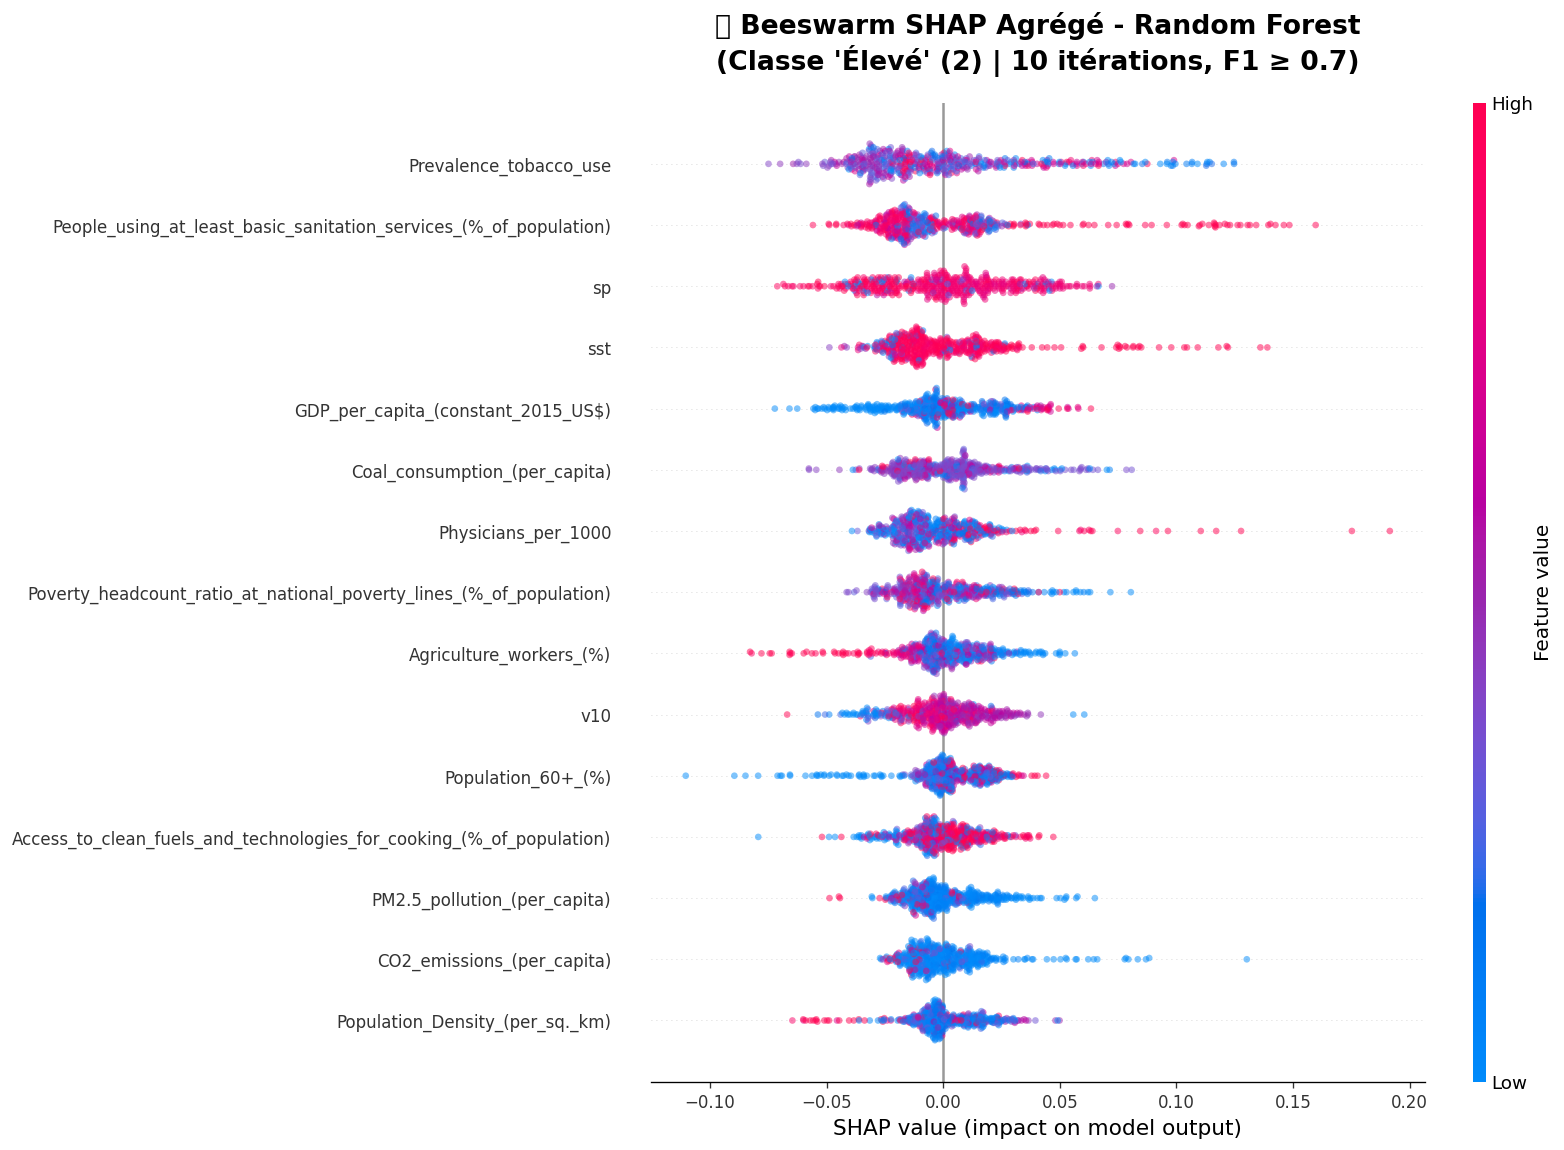

   💾 Sauvegardé: preprocessed_data/shap_beeswarm_aggregated_Random_Forest.png

🎨 Beeswarm AGRÉGÉ pour XGBoost
   📊 10 itérations | 500 échantillons


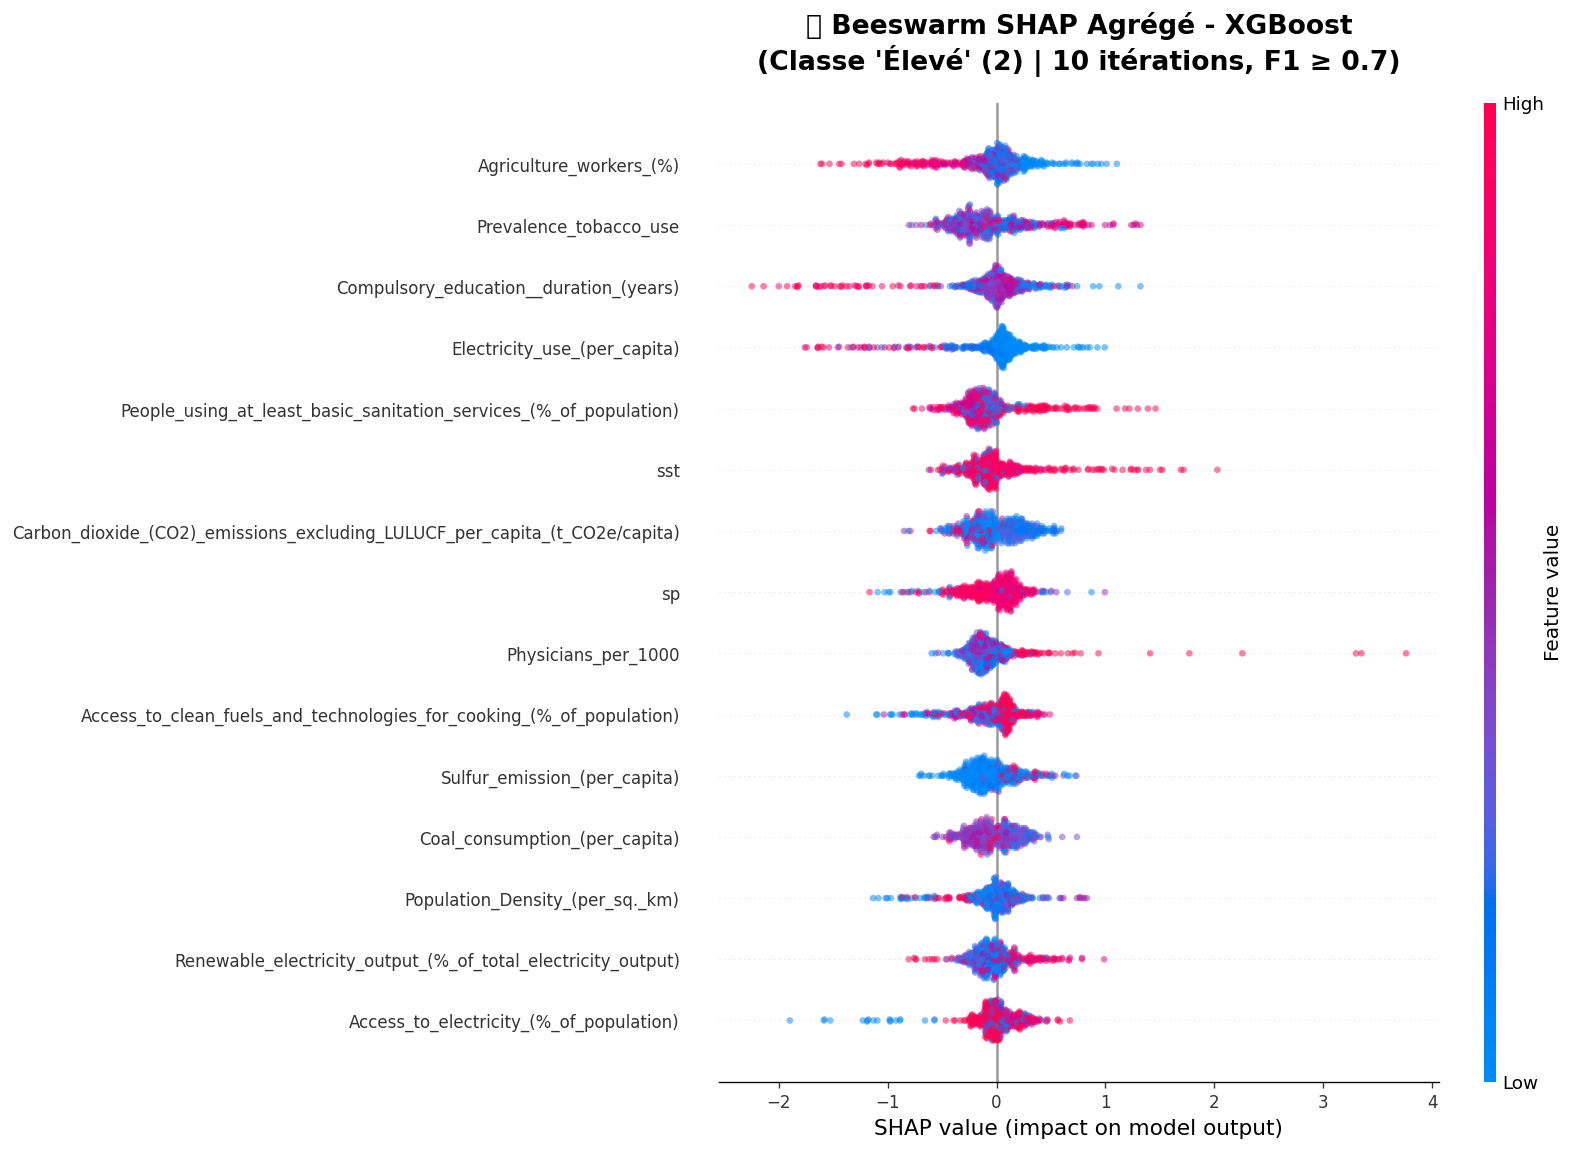

   💾 Sauvegardé: preprocessed_data/shap_beeswarm_aggregated_XGBoost.png

🎨 Beeswarm AGRÉGÉ pour LightGBM
   📊 10 itérations | 500 échantillons


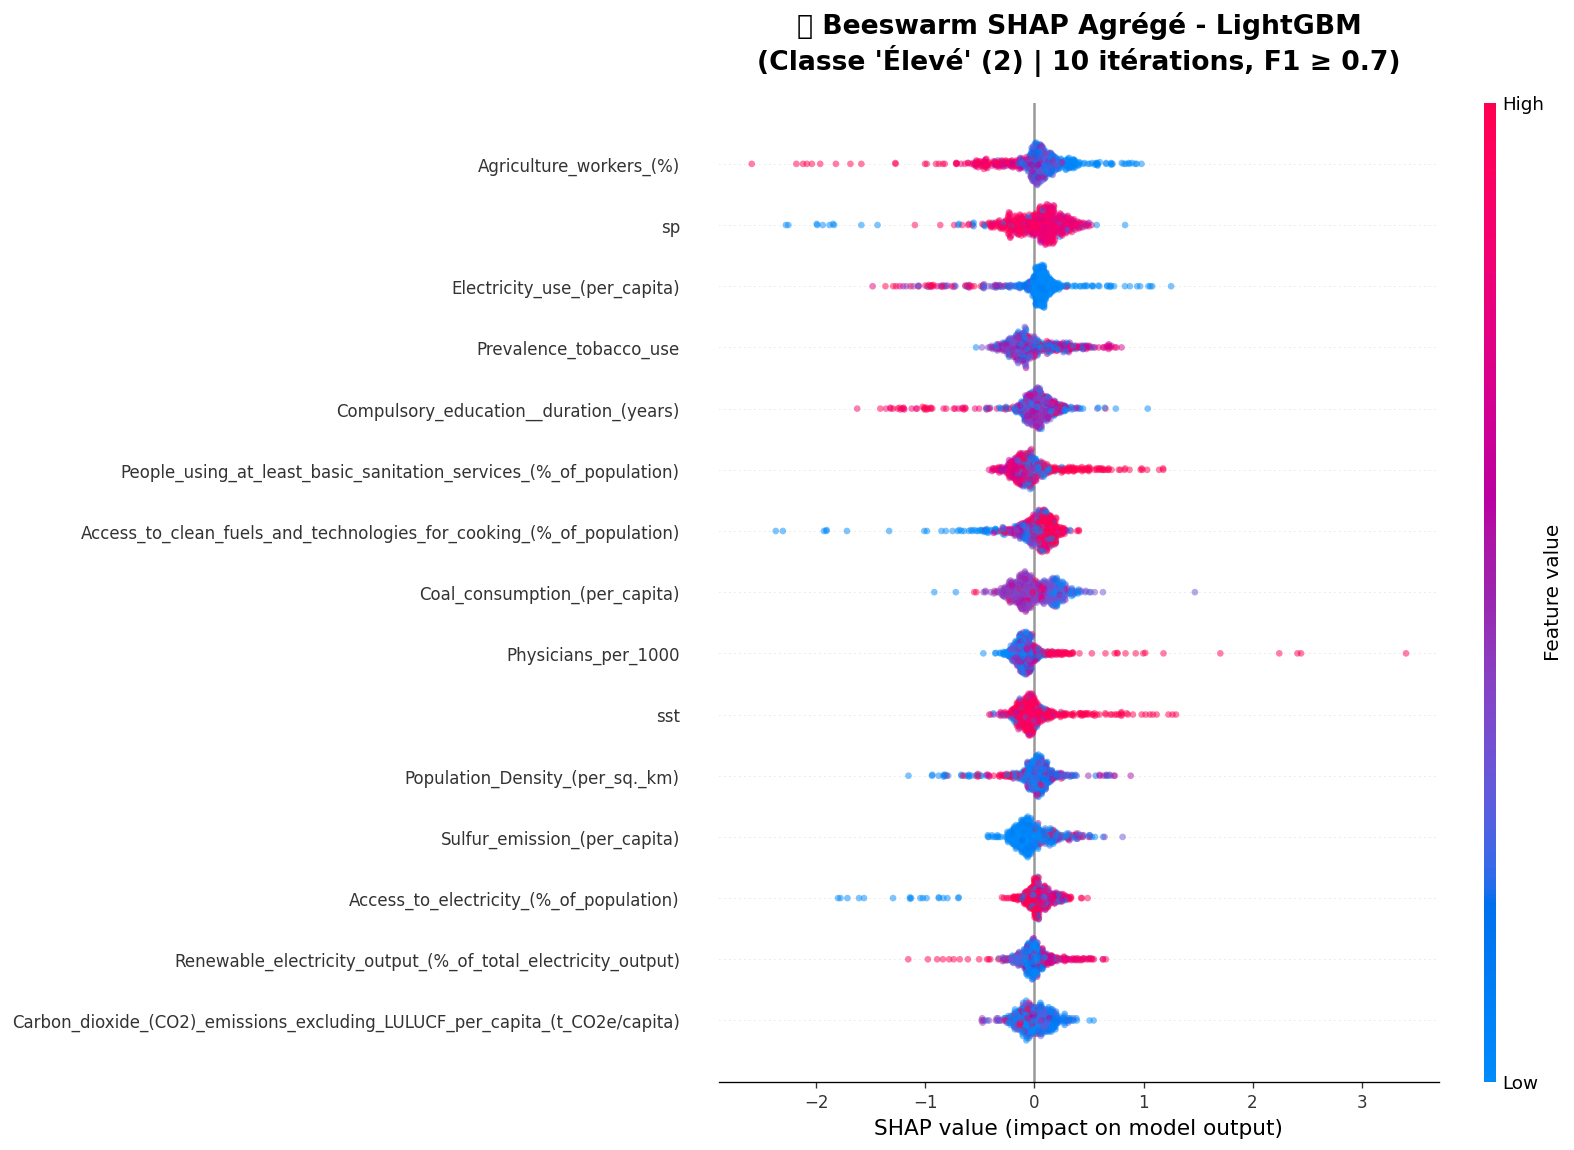

   💾 Sauvegardé: preprocessed_data/shap_beeswarm_aggregated_LightGBM.png

🎨 Beeswarm AGRÉGÉ pour CatBoost
   📊 10 itérations | 500 échantillons


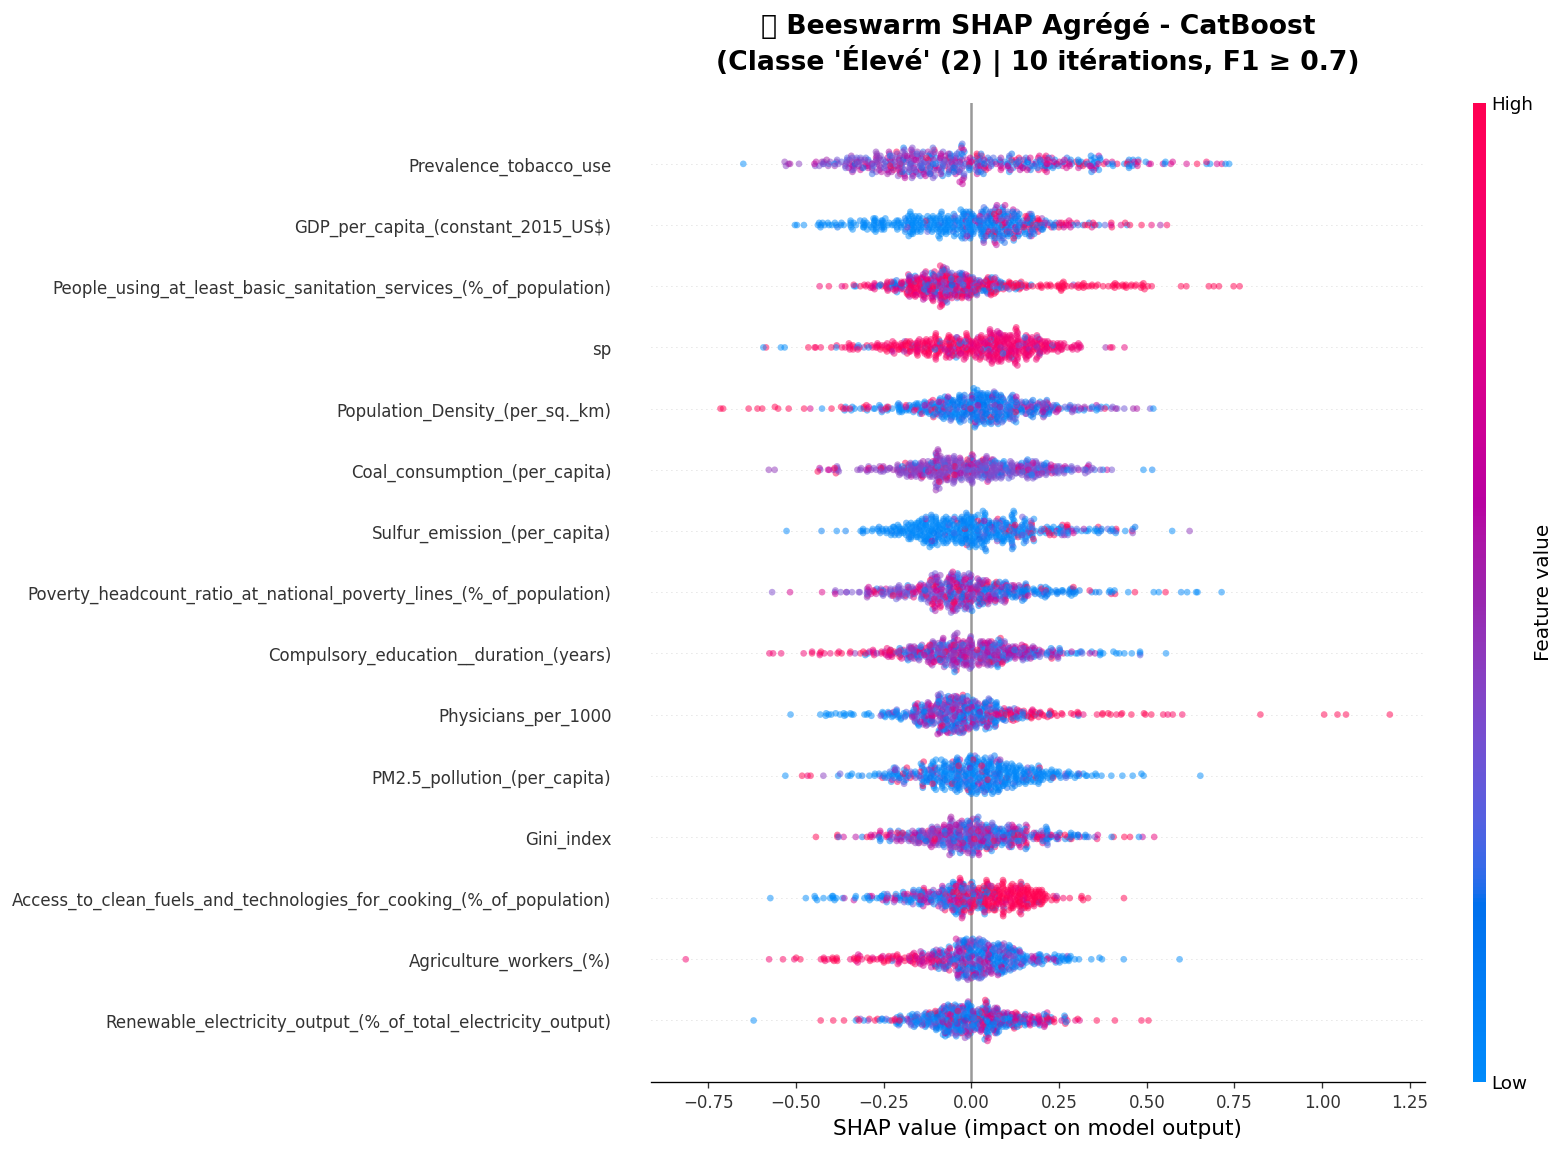

   💾 Sauvegardé: preprocessed_data/shap_beeswarm_aggregated_CatBoost.png

✅ 5 Beeswarm plots AGRÉGÉS générés avec succès!
   → Basés sur les valeurs SHAP de 10 répétitions (F1 ≥ 0.7)


In [28]:
# =============================================================================
# VISUALISATION SHAP : Beeswarm Plots AGRÉGÉS (Repeated Hold-Out)
# =============================================================================
# ⚠️ IMPORTANT : Ces plots utilisent les valeurs SHAP agrégées sur N_SPLITS
#    itérations qualifiées (F1 ≥ seuil), offrant une vue plus robuste
#    de l'importance des features.
#
# ⚠️ OPTIMISATIONS VISUELLES POUR RAPPORT PROFESSIONNEL :
#    - Figure agrandie (14x10) avec haute résolution (dpi=120)
#    - max_display=15 pour limiter le nombre de features
#    - alpha=0.6 pour la transparence des points
#    - Annotations indiquant le nombre d'itérations
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib

# Configuration globale Matplotlib pour de meilleurs graphiques
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("="*100)
print("📊 VISUALISATION SHAP - Beeswarm Plots AGRÉGÉS (Repeated Hold-Out)")
print("="*100)

n_models = len(aggregated_shap)

if n_models == 0:
    print("❌ Aucun résultat SHAP agrégé disponible pour la visualisation")
    print(f"   → Assurez-vous que les modèles atteignent F1 ≥ {F1_THRESHOLD}")
else:
    for model_name, data in aggregated_shap.items():
        print(f"\n{'='*60}")
        print(f"🎨 Beeswarm AGRÉGÉ pour {model_name}")
        print(f"   📊 {data['n_iterations']} itérations | {data['total_samples']} échantillons")
        print(f"{'='*60}")
        
        shap_vals_to_plot = data['shap_values']
        X_plot = data['X_data']
        class_info = data['class_info']
        n_iterations = data['n_iterations']
        
        # =================================================================
        # Génération du Beeswarm Plot AGRÉGÉ
        # =================================================================
        
        # 1. Initialiser une figure GRANDE avec haute résolution
        fig = plt.figure(figsize=(14, 10), dpi=120)
        
        # 2. Générer le summary plot avec paramètres optimisés
        shap.summary_plot(
            shap_vals_to_plot,
            X_plot,
            feature_names=feature_names,
            show=False,           # Permet personnalisation avant affichage
            max_display=15,       # Limiter à 15 features pour aérer
            plot_type="dot",      # Beeswarm plot
            alpha=0.5,            # Transparence réduite pour les données agrégées
            plot_size=(14, 10),   # Taille du plot SHAP
            color_bar=True        # Afficher la barre de couleur
        )
        
        # 3. Récupérer l'axe courant et ajuster
        ax = plt.gca()
        
        # 4. Ajouter un titre personnalisé avec info sur l'agrégation
        plt.title(
            f"🔍 Beeswarm SHAP Agrégé - {model_name}\n"
            f"({class_info} | {n_iterations} itérations, F1 ≥ {F1_THRESHOLD})", 
            fontsize=16, 
            fontweight='bold', 
            pad=20
        )
        
        # 5. Ajuster les labels de l'axe Y (noms des features)
        ax.tick_params(axis='y', labelsize=10)
        ax.tick_params(axis='x', labelsize=10)
        
        # 6. Ajouter des marges pour éviter les coupures
        plt.subplots_adjust(left=0.35, right=0.95, top=0.88, bottom=0.10)
        
        # 7. tight_layout avec padding supplémentaire
        plt.tight_layout(pad=2.0)
        
        # 8. Sauvegarder avec haute résolution
        safe_model_name = model_name.replace(" ", "_").replace("(", "").replace(")", "")
        fig_path = f"{output_dir}/shap_beeswarm_aggregated_{safe_model_name}.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
        
        # 9. Forcer l'affichage
        plt.show()
        
        # 10. Fermer la figure pour libérer la mémoire
        plt.close(fig)
        
        print(f"   💾 Sauvegardé: {fig_path}")

print("\n" + "="*100)
print(f"✅ {n_models} Beeswarm plots AGRÉGÉS générés avec succès!")
print(f"   → Basés sur les valeurs SHAP de {N_SPLITS} répétitions (F1 ≥ {F1_THRESHOLD})")
print("="*100)

📊 ANALYSE COMPARATIVE DES TOP FEATURES (SHAP Agrégé)

🔍 SVM (RBF):
   Format: Tableau 2D, forme: (500, 34)
   ✅ Importance calculée: 34 features

🔍 Random Forest:
   Format: Tableau 2D, forme: (500, 34)
   ✅ Importance calculée: 34 features

🔍 XGBoost:
   Format: Tableau 2D, forme: (500, 34)
   ✅ Importance calculée: 34 features

🔍 LightGBM:
   Format: Tableau 2D, forme: (500, 34)
   ✅ Importance calculée: 34 features

🔍 CatBoost:
   Format: Tableau 2D, forme: (500, 34)
   ✅ Importance calculée: 34 features

--------------------------------------------------

📈 Top 15 Features par Importance SHAP Moyenne (%):

                                                                            SVM (RBF)  Random Forest  XGBoost  LightGBM  CatBoost  Moyenne
Agriculture_workers_(%)                                                          9.68           3.43     5.58      6.33      3.28     5.66
Prevalence_tobacco_use                                                           4.02           7.02    

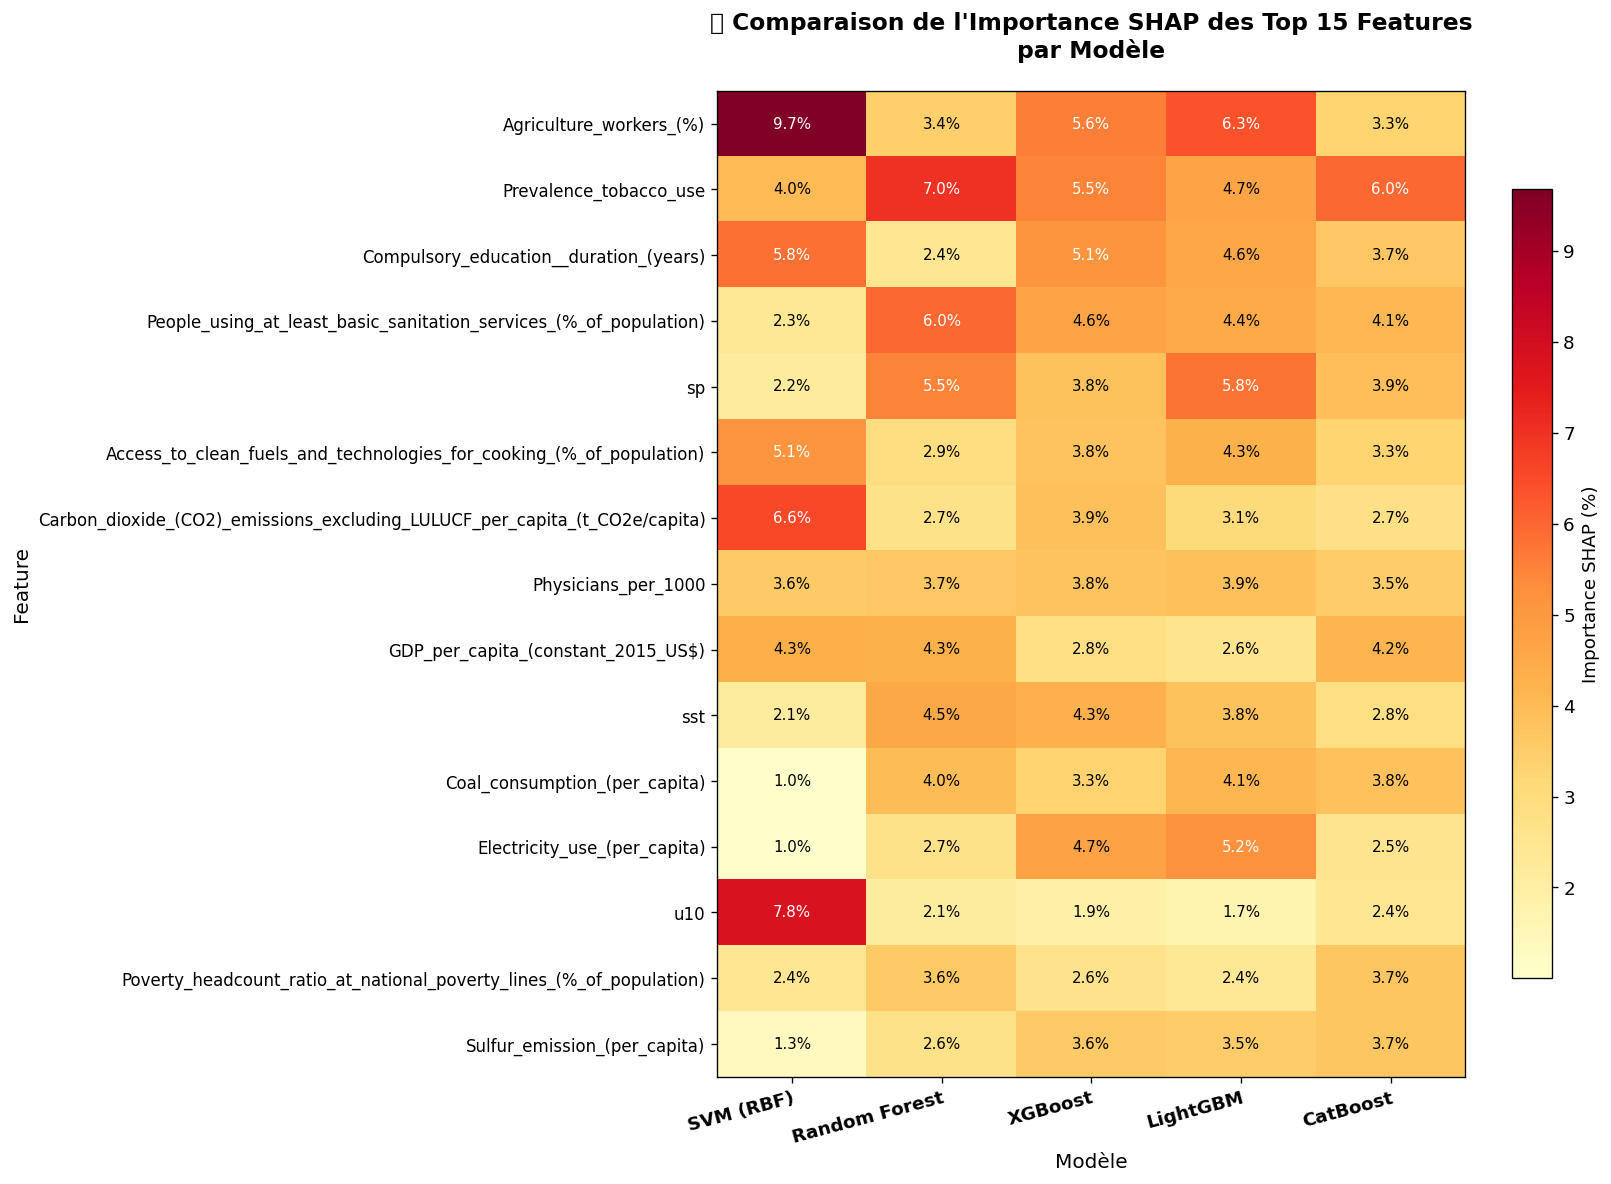


💾 Heatmap sauvegardée: preprocessed_data/shap_importance_heatmap_comparison.png


In [29]:
# =============================================================================
# ANALYSE COMPARATIVE : Top Features par Modèle (Importance Moyenne SHAP)
# Utilise les valeurs SHAP agrégées du repeated hold-out
# =============================================================================

print("="*100)
print("📊 ANALYSE COMPARATIVE DES TOP FEATURES (SHAP Agrégé)")
print("="*100)

# Calculer l'importance moyenne SHAP pour chaque modèle
shap_importance_comparison = {}

for model_name, data in aggregated_shap.items():
    shap_values = data['shap_values']
    
    print(f"\n🔍 {model_name}:")
    
    # Gérer les différents formats de sortie SHAP:
    # 1. Liste de tableaux (n_classes x [n_samples, n_features])
    # 2. Tableau 3D (n_samples, n_features, n_classes)
    # 3. Tableau 2D (n_samples, n_features) - cas binaire ou régression
    
    if isinstance(shap_values, list):
        # Format liste : Moyenne des valeurs absolues sur toutes les classes
        print(f"   Format: Liste de {len(shap_values)} classes, forme: {shap_values[0].shape}")
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        
    elif isinstance(shap_values, np.ndarray):
        if shap_values.ndim == 3:
            # Format 3D : (n_samples, n_features, n_classes)
            print(f"   Format: Tableau 3D, forme: {shap_values.shape}")
            # Moyenne sur les samples, puis moyenne sur les classes
            mean_abs_shap = np.abs(shap_values).mean(axis=0).mean(axis=1)
            
        elif shap_values.ndim == 2:
            # Format 2D : (n_samples, n_features)
            print(f"   Format: Tableau 2D, forme: {shap_values.shape}")
            mean_abs_shap = np.abs(shap_values).mean(axis=0)
        else:
            print(f"   ⚠️ Format non supporté: ndim={shap_values.ndim}")
            continue
    else:
        print(f"   ⚠️ Type non supporté: {type(shap_values)}")
        continue
    
    # Vérifier que la taille correspond au nombre de features
    if len(mean_abs_shap) != len(feature_names):
        print(f"   ⚠️ Taille incorrecte: {len(mean_abs_shap)} vs {len(feature_names)} features")
        continue
    
    # Normaliser pour avoir des pourcentages
    mean_abs_shap_pct = (mean_abs_shap / mean_abs_shap.sum()) * 100
    
    shap_importance_comparison[model_name] = mean_abs_shap_pct
    print(f"   ✅ Importance calculée: {len(mean_abs_shap_pct)} features")

print("\n" + "-"*50)

# Créer un DataFrame pour la comparaison
if len(shap_importance_comparison) > 0:
    df_shap_importance = pd.DataFrame(shap_importance_comparison, index=feature_names)
    df_shap_importance['Moyenne'] = df_shap_importance.mean(axis=1)
    df_shap_importance = df_shap_importance.sort_values('Moyenne', ascending=False)

    # Afficher le Top 15 des features
    print("\n📈 Top 15 Features par Importance SHAP Moyenne (%):\n")
    print(df_shap_importance.head(15).round(2).to_string())

    # Visualisation sous forme de heatmap
    fig, ax = plt.subplots(figsize=(14, 10))

    top15_shap = df_shap_importance.head(15).drop(columns=['Moyenne'])

    im = ax.imshow(top15_shap.values, cmap='YlOrRd', aspect='auto')

    # Labels
    ax.set_xticks(np.arange(len(top15_shap.columns)))
    ax.set_yticks(np.arange(len(top15_shap.index)))
    ax.set_xticklabels(top15_shap.columns, fontsize=11, fontweight='bold')
    ax.set_yticklabels(top15_shap.index, fontsize=10)

    # Rotation des labels
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", rotation_mode="anchor")

    # Ajouter les valeurs dans les cellules
    for i in range(len(top15_shap.index)):
        for j in range(len(top15_shap.columns)):
            val = top15_shap.values[i, j]
            text_color = "white" if val > top15_shap.values.max() * 0.5 else "black"
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center", color=text_color, fontsize=9)

    ax.set_title("🔍 Comparaison de l'Importance SHAP des Top 15 Features\npar Modèle", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Modèle", fontsize=12)
    ax.set_ylabel("Feature", fontsize=12)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Importance SHAP (%)', fontsize=11)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_importance_heatmap_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Heatmap sauvegardée: {output_dir}/shap_importance_heatmap_comparison.png")
else:
    print("❌ Aucune donnée SHAP disponible pour la comparaison")

In [30]:
# =============================================================================
# COHÉRENCE DES TOP FEATURES : Comparaison entre modèles
# =============================================================================

print("="*100)
print("🔗 ANALYSE DE COHÉRENCE DES TOP FEATURES ENTRE MODÈLES")
print("="*100)

# Identifier les Top 5 features de chaque modèle
top_n = 5
top_features_by_model_shap = {}

for model_name in shap_importance_comparison.keys():
    importance = shap_importance_comparison[model_name]
    top_idx = np.argsort(importance)[-top_n:][::-1]
    top_features_by_model_shap[model_name] = [feature_names[i] for i in top_idx]
    print(f"\n🏆 Top {top_n} Features - {model_name}:")
    for rank, feat_idx in enumerate(top_idx, 1):
        print(f"   {rank}. {feature_names[feat_idx]} ({importance[feat_idx]:.2f}%)")

# Trouver les features communes
all_top_features = []
for features in top_features_by_model_shap.values():
    all_top_features.extend(features)

# Compter la fréquence d'apparition dans les Top 5
from collections import Counter
feature_frequency = Counter(all_top_features)

print("\n" + "-"*50)
print("📊 Features les plus fréquentes dans les Top 5 de tous les modèles:")
print("-"*50)

for feat, count in feature_frequency.most_common():
    pct = (count / len(shap_importance_comparison)) * 100
    status = "✅ Consensus" if pct >= 75 else "⚠️ Partiel" if pct >= 50 else "❓ Variable"
    print(f"   {feat}: {count}/{len(shap_importance_comparison)} modèles ({pct:.0f}%) - {status}")

# Identifier les features en consensus total (présentes dans tous les modèles)
consensus_features = [feat for feat, count in feature_frequency.items() 
                      if count == len(shap_importance_comparison)]

print("\n" + "="*100)
if consensus_features:
    print(f"✅ FEATURES EN CONSENSUS TOTAL (Top {top_n} de TOUS les modèles):")
    for feat in consensus_features:
        print(f"   → {feat}")
else:
    print("⚠️ Aucune feature n'apparaît dans le Top 5 de TOUS les modèles")
    print("   Cela peut indiquer des stratégies de prédiction différentes selon les modèles")
print("="*100)

🔗 ANALYSE DE COHÉRENCE DES TOP FEATURES ENTRE MODÈLES

🏆 Top 5 Features - SVM (RBF):
   1. Agriculture_workers_(%) (9.68%)
   2. u10 (7.79%)
   3. Carbon_dioxide_(CO2)_emissions_excluding_LULUCF_per_capita_(t_CO2e/capita) (6.56%)
   4. Population_60+_(%) (6.19%)
   5. Compulsory_education__duration_(years) (5.84%)

🏆 Top 5 Features - Random Forest:
   1. Prevalence_tobacco_use (7.02%)
   2. People_using_at_least_basic_sanitation_services_(%_of_population) (5.98%)
   3. sp (5.50%)
   4. sst (4.53%)
   5. GDP_per_capita_(constant_2015_US$) (4.28%)

🏆 Top 5 Features - XGBoost:
   1. Agriculture_workers_(%) (5.58%)
   2. Prevalence_tobacco_use (5.50%)
   3. Compulsory_education__duration_(years) (5.09%)
   4. Electricity_use_(per_capita) (4.73%)
   5. People_using_at_least_basic_sanitation_services_(%_of_population) (4.63%)

🏆 Top 5 Features - LightGBM:
   1. Agriculture_workers_(%) (6.33%)
   2. sp (5.77%)
   3. Electricity_use_(per_capita) (5.20%)
   4. Prevalence_tobacco_use (4.66%)
   

📊 VISUALISATION FINALE : Comparaison des Importances SHAP


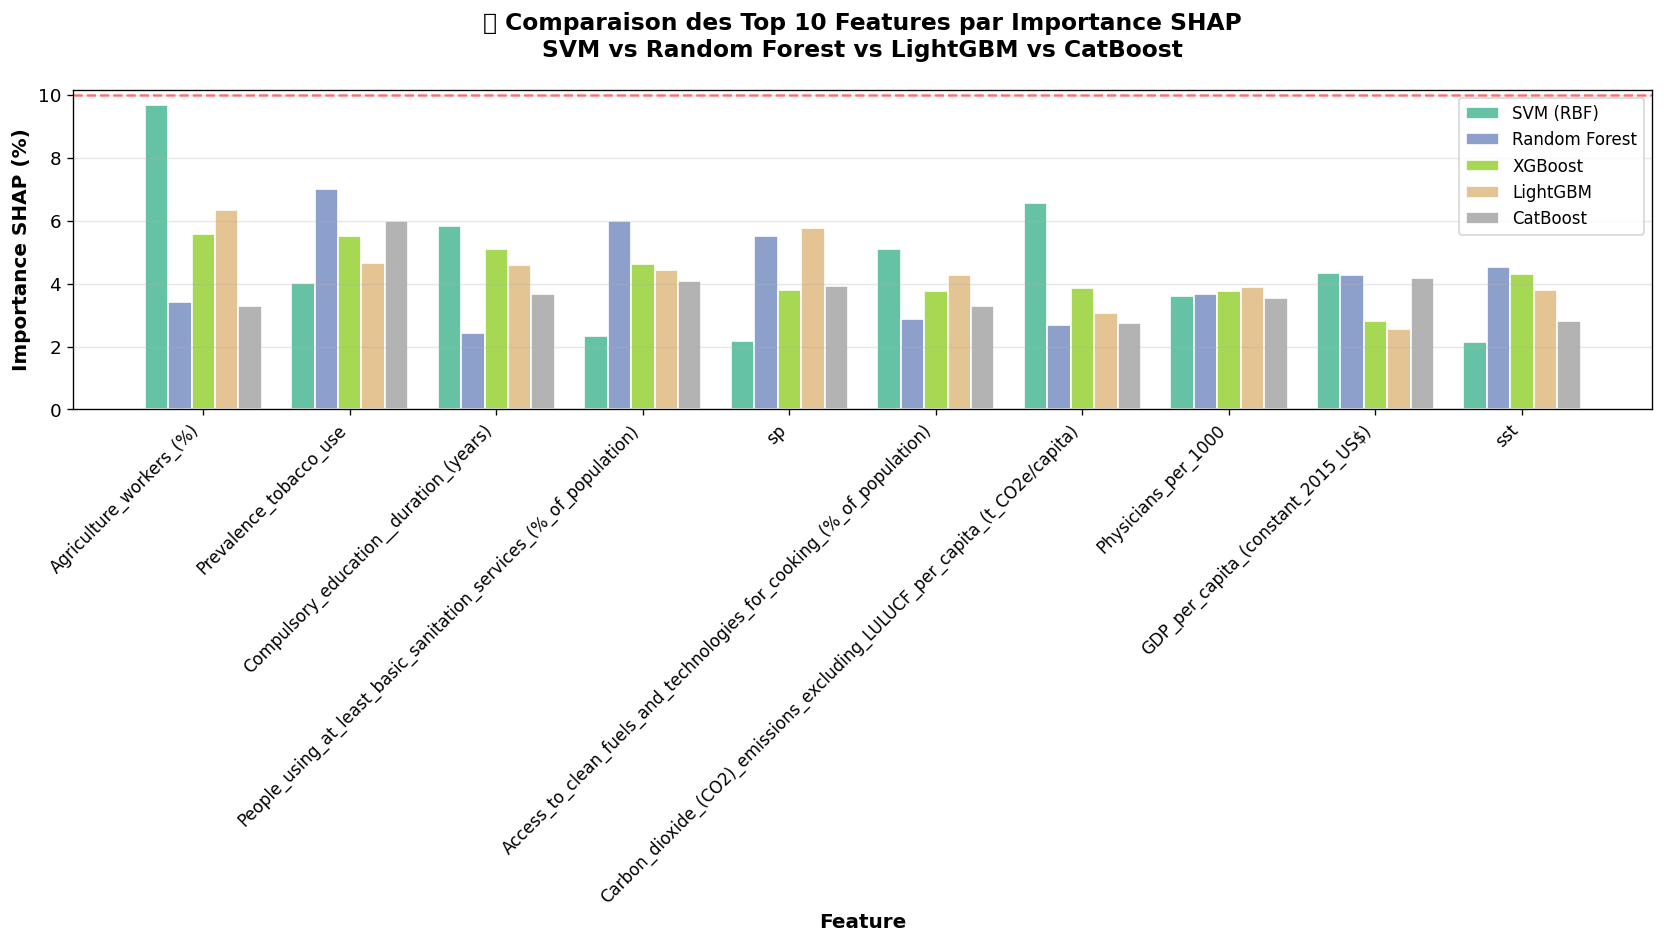


💾 Bar plot sauvegardé: preprocessed_data/shap_top10_comparison_barplot.png

📋 RÉSUMÉ DE L'ANALYSE SHAP COMPARATIVE (Repeated Hold-Out)

✅ Analyse réalisée sur 5 modèles: SVM (RBF), Random Forest, XGBoost, LightGBM, CatBoost

📊 Méthodes d'explication utilisées:
   - TreeExplainer: Random Forest, LightGBM, CatBoost, XGBoost (méthode exacte, rapide)
   - KernelExplainer: SVM (méthode agnostique, optimisée avec kmeans)

🔁 Repeated Hold-Out:
   - Valeurs SHAP agrégées sur 10 répétitions (F1 ≥ 0.7)

🔍 Points clés de l'interprétation:
   - Les valeurs SHAP positives indiquent une contribution vers la classe "Élevé"
   - Les valeurs SHAP négatives indiquent une contribution vers les classes "Faible/Moyen"
   - La cohérence des Top Features entre modèles renforce leur importance

📁 Fichiers générés:
   - preprocessed_data/shap_beeswarm_aggregated_*.png
   - preprocessed_data/shap_importance_heatmap_comparison.png
   - preprocessed_data/shap_top10_comparison_barplot.png



In [31]:
# =============================================================================
# VISUALISATION FINALE : Bar Plot Comparatif des Top 10 Features
# =============================================================================

print("="*100)
print("📊 VISUALISATION FINALE : Comparaison des Importances SHAP")
print("="*100)

# Sélectionner les Top 10 features globales
top10_features = df_shap_importance.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))

# Préparer les données pour le bar plot groupé
x = np.arange(len(top10_features))
width = 0.8 / len(shap_importance_comparison)
colors_shap = plt.cm.Set2(np.linspace(0, 1, len(shap_importance_comparison)))

for i, (model_name, importance) in enumerate(shap_importance_comparison.items()):
    # Récupérer les valeurs pour les top 10 features
    values = [importance[feature_names.index(f)] for f in top10_features]
    offset = (i - len(shap_importance_comparison)/2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=model_name, color=colors_shap[i], edgecolor='white')

ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance SHAP (%)', fontsize=12, fontweight='bold')
ax.set_title('🔍 Comparaison des Top 10 Features par Importance SHAP\nSVM vs Random Forest vs LightGBM vs CatBoost', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(top10_features, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Ajouter une ligne horizontale pour la moyenne
ax.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Seuil 10%')

plt.tight_layout()
plt.savefig(f"{output_dir}/shap_top10_comparison_barplot.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Bar plot sauvegardé: {output_dir}/shap_top10_comparison_barplot.png")

# =============================================================================
# RÉSUMÉ FINAL
# =============================================================================
print("\n" + "="*100)
print("📋 RÉSUMÉ DE L'ANALYSE SHAP COMPARATIVE (Repeated Hold-Out)")
print("="*100)
print(f"""
✅ Analyse réalisée sur {len(aggregated_shap)} modèles: {', '.join(aggregated_shap.keys())}

📊 Méthodes d'explication utilisées:
   - TreeExplainer: Random Forest, LightGBM, CatBoost, XGBoost (méthode exacte, rapide)
   - KernelExplainer: SVM (méthode agnostique, optimisée avec kmeans)

🔁 Repeated Hold-Out:
   - Valeurs SHAP agrégées sur {N_SPLITS} répétitions (F1 ≥ {F1_THRESHOLD})

🔍 Points clés de l'interprétation:
   - Les valeurs SHAP positives indiquent une contribution vers la classe "Élevé"
   - Les valeurs SHAP négatives indiquent une contribution vers les classes "Faible/Moyen"
   - La cohérence des Top Features entre modèles renforce leur importance

📁 Fichiers générés:
   - {output_dir}/shap_beeswarm_aggregated_*.png
   - {output_dir}/shap_importance_heatmap_comparison.png
   - {output_dir}/shap_top10_comparison_barplot.png
""")
print("="*100)